In [1]:
# Renko Chart Analysis Mean Reversion Strategy

#This notebook builds a Renko chart from historical OHLC data, calculates technical indicators, and generates buy/sell signals based on renko bricks .
    

Summary of Mean Reversion Strategy
Strategy Overview
Component	Description
Entry Type	Mean Reversion (fade extremes)
Long Entry	Z-Score < -1.65 AND Price < Inner Lower BB AND Price crosses above MA Fast
Short Entry	Z-Score > +1.65 AND Price > Inner Upper BB AND Price crosses below MA Fast
Scale Out	50% position when price crosses MA Fast in opposite direction
Full Exit	Remaining 50% when Stochastic crosses in overbought/oversold zone
Stop Loss	2 bricks from entry
Indicators Used
Indicator	Parameters	Purpose
Bollinger Bands (Outer)	20 period, 2 std dev	Extreme boundaries
Bollinger Bands (Inner)	20 period, 1.5 std dev	Entry trigger zone
Z-Score	20 period, ±1.65 threshold	Oversold/Overbought detection
MA Mean Target	20 period	Mean reversion target
MA Fast	3 period	Entry/Exit timing
Stochastic	K=10, D=7, Smoothing=3	Exit confirmation
Chart Legend
Symbol	Meaning
▲ (Lime)	Long Entry
▼ (Magenta)	Short Entry
■ (Cyan)	Scale Out (50%)
✕ (Yellow)	Full Exit
Orange Lines	Inner Bollinger Bands
Red Dashed Lines	Outer Bollinger Bands
Blue Line	MA 20 (Mean Target)
Purple Line	MA Fast (3)
Red Dotted Line	Stop Loss Level

In [2]:
## 1. Import Libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [3]:
# Ticker and date range
ticker = 'CL=F'
start_date = '2025-01-01'
end_date = '2026-01-01'

# Renko brick size
brick_size = 0.05  # Adjust as needed (can be calculated dynamically)

# ========== MEAN REVERSION STRATEGY PARAMETERS ==========

# Bollinger Bands Parameters
BOLLINGER_BAND_PERIOD_OUTER = 20
BOLLINGER_BAND_STD_DEV_OUTER = 2.0
BOLLINGER_BAND_PERIOD_INNER = 20
BOLLINGER_BAND_STD_DEV_INNER = 1.5

# Z-Score Parameters
Z_SCORE_PERIOD = 20
Z_SCORE_EXTREME_THRESHOLD = 1.65  # +/- 1.65

# Moving Average Parameters
MA_MEAN_TARGET_PERIOD = 20        # Central moving average for mean target
MA_FAST_ENTRY_EXIT_PERIOD = 3     # Fast MA for entry/exit signals
MA_FAST_ENTRY_EXIT_OFFSET = 1     # Offset for quick entry/exit MA

# Stochastic Parameters
STOCHASTIC_K_PERIOD = 10
STOCHASTIC_D_PERIOD = 7
STOCHASTIC_SMOOTHING_PERIOD = 3
STOCHASTIC_EXIT_LEVEL_LONG = 20   # Below 20 for long exit
STOCHASTIC_EXIT_LEVEL_SHORT = 80  # Above 80 for short exit

# Stop Loss (in number of bricks)
STOP_LOSS_BRICKS = 2

In [4]:
# Download OHLC data from Yahoo Finance
df = yf.download(ticker, start=start_date, end=end_date)

# Flatten MultiIndex columns (fix for newer yfinance versions)
df.columns = df.columns.get_level_values(0)

# Keep only the essential columns
df = df[['Open', 'High', 'Low', 'Close']]

# Reset index to get Date as a column
df = df.reset_index()

# Display first few rows
df.head()

/var/folders/2v/mkg1tcnj0dsgbn4wspnx8l0h0000gn/T/ipykernel_97419/2983682258.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price,Date,Open,High,Low,Close
0,2025-01-02,71.849998,73.730003,71.790001,73.129997
1,2025-01-03,73.129997,74.349998,72.699997,73.959999
2,2025-01-06,74.050003,74.989998,73.199997,73.559998
3,2025-01-07,73.440002,74.529999,73.110001,74.250000
4,2025-01-08,74.519997,75.290001,73.160004,73.320000


In [5]:
# Convert Close prices and dates to lists
prices = df['Close'].values.flatten().tolist()
dates = df['Date'].tolist()

renko_data = []      # Stores price levels of each brick
directions = []      # 1 = up, -1 = down, 0 = neutral (first brick)
renko_dates = []     # Stores the date when each brick was formed

last_price = prices[0]
renko_data.append(last_price)
directions.append(0)
renko_dates.append(dates[0])

for idx, price in enumerate(prices):
    diff = price - last_price
    brick_moves = int(diff / brick_size)

    while brick_moves != 0:
        if brick_moves > 0:
            last_price += brick_size
            renko_data.append(last_price)
            directions.append(1)
            renko_dates.append(dates[idx])
            brick_moves -= 1
        elif brick_moves < 0:
            last_price -= brick_size
            renko_data.append(last_price)
            directions.append(-1)
            renko_dates.append(dates[idx])
            brick_moves += 1

print(f"Total Renko bricks: {len(renko_data)}")
print(f"Date range: {renko_dates[0]} to {renko_dates[-1]}")

Total Renko bricks: 4691
Date range: 2025-01-02 00:00:00 to 2025-12-31 00:00:00


In [6]:
## 5. Calculate X and Y Positions for Bricks
x_positions = [0]
y_positions = [renko_data[0]]

for i in range(1, len(renko_data)):
    prev_x = x_positions[-1]
    prev_y = y_positions[-1]
    
    if renko_data[i] > renko_data[i-1]:
        x_positions.append(prev_x + 1)
        y_positions.append(prev_y + brick_size)
    else:
        x_positions.append(prev_x + 1)
        y_positions.append(prev_y - brick_size)

In [7]:
# Create DataFrame for Renko data
renko_df = pd.DataFrame({
    'X': x_positions,
    'Y': y_positions,
    'Price': renko_data,
    'Direction': directions,
    'Date': renko_dates
})

# Convert Date to datetime if not already
renko_df['Date'] = pd.to_datetime(renko_df['Date'])

# ========== BOLLINGER BANDS (OUTER) ==========
renko_df['BB_Middle_Outer'] = renko_df['Price'].rolling(window=BOLLINGER_BAND_PERIOD_OUTER).mean()
renko_df['BB_StdDev_Outer'] = renko_df['Price'].rolling(window=BOLLINGER_BAND_PERIOD_OUTER).std()
renko_df['BB_Upper_Outer'] = renko_df['BB_Middle_Outer'] + (BOLLINGER_BAND_STD_DEV_OUTER * renko_df['BB_StdDev_Outer'])
renko_df['BB_Lower_Outer'] = renko_df['BB_Middle_Outer'] - (BOLLINGER_BAND_STD_DEV_OUTER * renko_df['BB_StdDev_Outer'])

# ========== BOLLINGER BANDS (INNER) ==========
renko_df['BB_Middle_Inner'] = renko_df['Price'].rolling(window=BOLLINGER_BAND_PERIOD_INNER).mean()
renko_df['BB_StdDev_Inner'] = renko_df['Price'].rolling(window=BOLLINGER_BAND_PERIOD_INNER).std()
renko_df['BB_Upper_Inner'] = renko_df['BB_Middle_Inner'] + (BOLLINGER_BAND_STD_DEV_INNER * renko_df['BB_StdDev_Inner'])
renko_df['BB_Lower_Inner'] = renko_df['BB_Middle_Inner'] - (BOLLINGER_BAND_STD_DEV_INNER * renko_df['BB_StdDev_Inner'])

# ========== Z-SCORE ==========
renko_df['Z_Mean'] = renko_df['Price'].rolling(window=Z_SCORE_PERIOD).mean()
renko_df['Z_StdDev'] = renko_df['Price'].rolling(window=Z_SCORE_PERIOD).std()
renko_df['Z_Score'] = (renko_df['Price'] - renko_df['Z_Mean']) / renko_df['Z_StdDev']

# ========== MOVING AVERAGES ==========
# MA Mean Target (20 period)
renko_df['MA_Mean_Target'] = renko_df['Price'].rolling(window=MA_MEAN_TARGET_PERIOD).mean()

# MA Fast Entry/Exit (3 period with offset)
renko_df['MA_Fast'] = renko_df['Price'].rolling(window=MA_FAST_ENTRY_EXIT_PERIOD).mean()
renko_df['MA_Fast_Offset'] = renko_df['MA_Fast'].shift(MA_FAST_ENTRY_EXIT_OFFSET)

# Previous values for crossover detection
renko_df['Price_prev'] = renko_df['Price'].shift(1)
renko_df['MA_Fast_prev'] = renko_df['MA_Fast'].shift(1)
renko_df['MA_Fast_Offset_prev'] = renko_df['MA_Fast_Offset'].shift(1)

# ========== STOCHASTIC OSCILLATOR ==========
renko_df['Lowest'] = renko_df['Price'].rolling(window=STOCHASTIC_K_PERIOD).min()
renko_df['Highest'] = renko_df['Price'].rolling(window=STOCHASTIC_K_PERIOD).max()
renko_df['%K_raw'] = 100 * (renko_df['Price'] - renko_df['Lowest']) / (renko_df['Highest'] - renko_df['Lowest'])
renko_df['%K'] = renko_df['%K_raw'].rolling(window=STOCHASTIC_SMOOTHING_PERIOD).mean()
renko_df['%D'] = renko_df['%K'].rolling(window=STOCHASTIC_D_PERIOD).mean()

# Stochastic previous values for crossover
renko_df['%K_prev'] = renko_df['%K'].shift(1)
renko_df['%D_prev'] = renko_df['%D'].shift(1)

# Initialize Signal columns
renko_df['Signal'] = 0
renko_df['Exit_Signal'] = 0

# Display data availability info
first_valid_idx = max(
    renko_df['BB_Middle_Outer'].first_valid_index() or 0,
    renko_df['Z_Score'].first_valid_index() or 0,
    renko_df['MA_Fast'].first_valid_index() or 0,
    renko_df['%K'].first_valid_index() or 0
)

print(f"Total Renko Bricks: {len(renko_df)}")
print(f"Indicators available from brick: {first_valid_idx}")
print(f"Bricks available for trading: {len(renko_df) - first_valid_idx}")
print(f"Date range: {renko_df['Date'].min().strftime('%Y-%m-%d')} to {renko_df['Date'].max().strftime('%Y-%m-%d')}")

renko_df.head(25)

Total Renko Bricks: 4691
Indicators available from brick: 19
Bricks available for trading: 4672
Date range: 2025-01-02 to 2025-12-31


,X,Y,Price,Direction,Date,BB_Middle_Outer,BB_StdDev_Outer,BB_Upper_Outer,BB_Lower_Outer,BB_Middle_Inner,...,MA_Fast_Offset_prev,Lowest,Highest,%K_raw,%K,%D,%K_prev,%D_prev,Signal,Exit_Signal
0,0,73.129997,73.129997,0,2025-01-02,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
1,1,73.179997,73.179997,1,2025-01-03,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
2,2,73.229997,73.229997,1,2025-01-03,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
3,3,73.279997,73.279997,1,2025-01-03,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
4,4,73.329997,73.329997,1,2025-01-03,NaN,NaN,NaN,NaN,NaN,...,73.179997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
5,5,73.379997,73.379997,1,2025-01-03,NaN,NaN,NaN,NaN,NaN,...,73.229997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
6,6,73.429997,73.429997,1,2025-01-03,NaN,NaN,NaN,NaN,NaN,...,73.279997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
7,7,73.479997,73.479997,1,2025-01-03,NaN,NaN,NaN,NaN,NaN,...,73.329997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
8,8,73.529997,73.529997,1,2025-01-03,NaN,NaN,NaN,NaN,NaN,...,73.379997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
9,9,73.579997,73.579997,1,2025-01-03,NaN,NaN,NaN,NaN,NaN,...,73.429997,73.129997,73.579997,100.000000,NaN,NaN,NaN,NaN,0,0


## 7. Define Parameters and Execute Mean Reversion Strategy

### Strategy Rules:

**Long Entry:**
- Z-Score < -1.65 (oversold condition)
- Price < Inner Lower Bollinger Band
- Price crosses above MA Fast (3-period)

**Short Entry:**
- Z-Score > +1.65 (overbought condition)
- Price > Inner Upper Bollinger Band
- Price crosses below MA Fast (3-period)

**Exit Conditions:**
- **Scale Out (Half Position):** Price crosses MA Fast in opposite direction
- **Full Exit (Remaining Half):** Stochastic %K crosses %D in oversold/overbought zone

**Stop Loss:**
- 2 bricks from entry price

In [8]:
# Trading Parameters
initial_capital = 10000
risk_per_trade = 0.01   # 1% risk
position_size = 1       # We'll adjust this later

# Reset trading parameters
capital = initial_capital
equity_curve = []
trade_log = []
daily_pnl = []
cumulative_pnl = []

# Position tracking
in_long = False
in_short = False
entry_price = 0
position_size = 0
risk_amount = 0
stop_loss_price = 0

# Scale out tracking
half_position_scaled_out = False
remaining_position_size = 0

# Stochastic level tracking for exit
stoch_crossed_above_80 = False  # For LONG: tracks if %K crossed above 80
stoch_crossed_below_20 = False  # For SHORT: tracks if %K crossed below 20

# Signal counters
long_entry_count = 0
short_entry_count = 0
long_exit_count = 0
short_exit_count = 0
scale_out_count = 0
stop_loss_count = 0
full_exit_both_conditions_count = 0  # NEW: Track when both conditions hit together

running_pnl = 0
previous_capital = initial_capital

# Lookback period for entry conditions
ENTRY_LOOKBACK = 2

# Stochastic levels for exit
STOCH_OVERBOUGHT_LEVEL = 80
STOCH_OVERSOLD_LEVEL = 20

# Debug tracking
debug_all_crossovers = {'long': [], 'short': []}
debug_entries_skipped = {'long': [], 'short': []}

for i in range(1, len(renko_df)):
    current_price = renko_df.loc[i, 'Price']
    prev_price = renko_df.loc[i, 'Price_prev']
    current_date = renko_df.loc[i, 'Date']
    direction = renko_df.loc[i, 'Direction']
    
    # Get indicator values
    z_score = renko_df.loc[i, 'Z_Score']
    bb_upper_inner = renko_df.loc[i, 'BB_Upper_Inner']
    bb_lower_inner = renko_df.loc[i, 'BB_Lower_Inner']
    ma_fast = renko_df.loc[i, 'MA_Fast']
    ma_fast_prev = renko_df.loc[i, 'MA_Fast_prev']
    ma_mean_target = renko_df.loc[i, 'MA_Mean_Target']
    
    # Stochastic values
    k_current = renko_df.loc[i, '%K']
    k_prev = renko_df.loc[i, '%K_prev']
    d_current = renko_df.loc[i, '%D']
    d_prev = renko_df.loc[i, '%D_prev']
    
    # Skip if any required values are NaN
    if (pd.isna(z_score) or pd.isna(bb_lower_inner) or pd.isna(ma_fast) or 
        pd.isna(k_current) or pd.isna(ma_fast_prev) or pd.isna(prev_price) or pd.isna(k_prev)):
        equity_curve.append(capital)
        daily_pnl.append(0)
        cumulative_pnl.append(running_pnl)
        previous_capital = capital
        continue
    
    # Track PnL for this brick
    brick_pnl = 0
    
    # Crossover detection for entry signals
    price_crosses_above_ma_fast = (prev_price < ma_fast_prev) and (current_price > ma_fast)
    price_crosses_below_ma_fast = (prev_price > ma_fast_prev) and (current_price < ma_fast)
    
    if price_crosses_above_ma_fast:
        debug_all_crossovers['long'].append(i)
    if price_crosses_below_ma_fast:
        debug_all_crossovers['short'].append(i)
    
    # ========== STOP LOSS CHECK ==========
    
    if in_long and current_price <= stop_loss_price:
        exit_price = stop_loss_price
        pnl = (exit_price - entry_price) * (position_size if not half_position_scaled_out else remaining_position_size)
        capital += pnl
        running_pnl += pnl
        brick_pnl = pnl
        in_long = False
        stop_loss_count += 1
        long_exit_count += 1
        
        rr_ratio = pnl / risk_amount if risk_amount != 0 else 0
        
        trade_log[-1].update({
            'Exit_Brick': i,
            'Exit_Price': exit_price,
            'Exit_Date': current_date,
            'Exit_Type': 'STOP LOSS',
            'PnL': trade_log[-1].get('PnL', 0) + pnl,
            'Capital': capital,
            'RR_Ratio': rr_ratio
        })
        
        # Reset tracking
        half_position_scaled_out = False
        remaining_position_size = 0
        stoch_crossed_above_80 = False
    
    if in_short and current_price >= stop_loss_price:
        exit_price = stop_loss_price
        pnl = (entry_price - exit_price) * (position_size if not half_position_scaled_out else remaining_position_size)
        capital += pnl
        running_pnl += pnl
        brick_pnl = pnl
        in_short = False
        stop_loss_count += 1
        short_exit_count += 1
        
        rr_ratio = pnl / risk_amount if risk_amount != 0 else 0
        
        trade_log[-1].update({
            'Exit_Brick': i,
            'Exit_Price': exit_price,
            'Exit_Date': current_date,
            'Exit_Type': 'STOP LOSS',
            'PnL': trade_log[-1].get('PnL', 0) + pnl,
            'Capital': capital,
            'RR_Ratio': rr_ratio
        })
        
        # Reset tracking
        half_position_scaled_out = False
        remaining_position_size = 0
        stoch_crossed_below_20 = False
    
    # ========== LONG POSITION EXITS ==========
    
    if in_long:
        # Detect exit trigger conditions FIRST
        ma_cross_down = (prev_price >= ma_fast_prev) and (current_price < ma_fast)
        k_crosses_above_80 = (k_prev < STOCH_OVERBOUGHT_LEVEL) and (k_current >= STOCH_OVERBOUGHT_LEVEL)
        k_crosses_below_80 = (k_prev >= STOCH_OVERBOUGHT_LEVEL) and (k_current < STOCH_OVERBOUGHT_LEVEL)
        
        # Track if %K has crossed above 80 (track BEFORE checking exits)
        if k_crosses_above_80:
            stoch_crossed_above_80 = True
        
        # Check if stochastic exit condition is ready
        stoch_exit_ready = stoch_crossed_above_80 and k_crosses_below_80
        
        if not half_position_scaled_out:
            # Check if BOTH exit conditions are met - exit FULL position
            if ma_cross_down and stoch_exit_ready:
                exit_price = current_price
                full_pnl = (exit_price - entry_price) * position_size
                capital += full_pnl
                running_pnl += full_pnl
                brick_pnl += full_pnl
                in_long = False
                long_exit_count += 1
                full_exit_both_conditions_count += 1
                
                rr_ratio = full_pnl / risk_amount if risk_amount != 0 else 0
                
                trade_log[-1].update({
                    'Exit_Brick': i,
                    'Exit_Price': exit_price,
                    'Exit_Date': current_date,
                    'Exit_Type': 'FULL EXIT (MA + %K<80)',
                    'PnL': full_pnl,
                    'Capital': capital,
                    'RR_Ratio': rr_ratio
                })
                
                # Reset tracking
                half_position_scaled_out = False
                remaining_position_size = 0
                stoch_crossed_above_80 = False
                
            elif ma_cross_down:
                # Only MA cross - scale out first 50%
                exit_price = current_price
                half_pnl = (exit_price - entry_price) * (position_size / 2)
                capital += half_pnl
                running_pnl += half_pnl
                brick_pnl += half_pnl
                half_position_scaled_out = True
                remaining_position_size = position_size / 2
                scale_out_count += 1
                
                # NOTE: Do NOT reset stoch_crossed_above_80 here - keep tracking for remaining 50%
                
                trade_log[-1].update({
                    'Scale_Out_Brick': i,
                    'Scale_Out_Price': exit_price,
                    'Scale_Out_Date': current_date,
                    'Scale_Out_PnL': half_pnl,
                    'PnL': half_pnl
                })
                
            elif stoch_exit_ready:
                # Only stochastic exit (no MA cross) - exit full position
                # This handles the case where stochastic exits before MA cross
                exit_price = current_price
                full_pnl = (exit_price - entry_price) * position_size
                capital += full_pnl
                running_pnl += full_pnl
                brick_pnl += full_pnl
                in_long = False
                long_exit_count += 1
                
                rr_ratio = full_pnl / risk_amount if risk_amount != 0 else 0
                
                trade_log[-1].update({
                    'Exit_Brick': i,
                    'Exit_Price': exit_price,
                    'Exit_Date': current_date,
                    'Exit_Type': '%K<80 BEFORE MA CROSS (Full)',
                    'PnL': full_pnl,
                    'Capital': capital,
                    'RR_Ratio': rr_ratio
                })
                
                # Reset tracking
                stoch_crossed_above_80 = False
                
        else:
            # Already scaled out - waiting for stochastic exit for remaining 50%
            # Track if %K crosses above 80 (in case it crosses again after scale out)
            if k_crosses_above_80:
                stoch_crossed_above_80 = True
            
            # Exit remaining 50% when %K crosses back below 80
            if stoch_crossed_above_80 and k_crosses_below_80:
                exit_price = current_price
                remaining_pnl = (exit_price - entry_price) * remaining_position_size
                capital += remaining_pnl
                running_pnl += remaining_pnl
                brick_pnl += remaining_pnl
                in_long = False
                long_exit_count += 1
                
                total_pnl = trade_log[-1].get('Scale_Out_PnL', 0) + remaining_pnl
                rr_ratio = total_pnl / risk_amount if risk_amount != 0 else 0
                
                trade_log[-1].update({
                    'Exit_Brick': i,
                    'Exit_Price': exit_price,
                    'Exit_Date': current_date,
                    'Exit_Type': '%K CROSSED BACK BELOW 80',
                    'PnL': total_pnl,
                    'Capital': capital,
                    'RR_Ratio': rr_ratio
                })
                
                # Reset tracking
                half_position_scaled_out = False
                remaining_position_size = 0
                stoch_crossed_above_80 = False
    
    # ========== SHORT POSITION EXITS ==========
    
    if in_short:
        # Detect exit trigger conditions FIRST
        ma_cross_up = (prev_price <= ma_fast_prev) and (current_price > ma_fast)
        k_crosses_below_20 = (k_prev > STOCH_OVERSOLD_LEVEL) and (k_current <= STOCH_OVERSOLD_LEVEL)
        k_crosses_above_20 = (k_prev <= STOCH_OVERSOLD_LEVEL) and (k_current > STOCH_OVERSOLD_LEVEL)
        
        # Track if %K has crossed below 20 (track BEFORE checking exits)
        if k_crosses_below_20:
            stoch_crossed_below_20 = True
        
        # Check if stochastic exit condition is ready
        stoch_exit_ready = stoch_crossed_below_20 and k_crosses_above_20
        
        if not half_position_scaled_out:
            # Check if BOTH exit conditions are met - exit FULL position
            if ma_cross_up and stoch_exit_ready:
                exit_price = current_price
                full_pnl = (entry_price - exit_price) * position_size
                capital += full_pnl
                running_pnl += full_pnl
                brick_pnl += full_pnl
                in_short = False
                short_exit_count += 1
                full_exit_both_conditions_count += 1
                
                rr_ratio = full_pnl / risk_amount if risk_amount != 0 else 0
                
                trade_log[-1].update({
                    'Exit_Brick': i,
                    'Exit_Price': exit_price,
                    'Exit_Date': current_date,
                    'Exit_Type': 'FULL EXIT (MA + %K>20)',
                    'PnL': full_pnl,
                    'Capital': capital,
                    'RR_Ratio': rr_ratio
                })
                
                # Reset tracking
                half_position_scaled_out = False
                remaining_position_size = 0
                stoch_crossed_below_20 = False
                
            elif ma_cross_up:
                # Only MA cross - scale out first 50%
                exit_price = current_price
                half_pnl = (entry_price - exit_price) * (position_size / 2)
                capital += half_pnl
                running_pnl += half_pnl
                brick_pnl += half_pnl
                half_position_scaled_out = True
                remaining_position_size = position_size / 2
                scale_out_count += 1
                
                # NOTE: Do NOT reset stoch_crossed_below_20 here
                
                trade_log[-1].update({
                    'Scale_Out_Brick': i,
                    'Scale_Out_Price': exit_price,
                    'Scale_Out_Date': current_date,
                    'Scale_Out_PnL': half_pnl,
                    'PnL': half_pnl
                })
                
            elif stoch_exit_ready:
                # Only stochastic exit (no MA cross) - exit full position
                exit_price = current_price
                full_pnl = (entry_price - exit_price) * position_size
                capital += full_pnl
                running_pnl += full_pnl
                brick_pnl += full_pnl
                in_short = False
                short_exit_count += 1
                
                rr_ratio = full_pnl / risk_amount if risk_amount != 0 else 0
                
                trade_log[-1].update({
                    'Exit_Brick': i,
                    'Exit_Price': exit_price,
                    'Exit_Date': current_date,
                    'Exit_Type': '%K>20 BEFORE MA CROSS (Full)',
                    'PnL': full_pnl,
                    'Capital': capital,
                    'RR_Ratio': rr_ratio
                })
                
                # Reset tracking
                stoch_crossed_below_20 = False
                
        else:
            # Already scaled out - waiting for stochastic exit for remaining 50%
            if k_crosses_below_20:
                stoch_crossed_below_20 = True
            
            # Exit remaining 50% when %K crosses back above 20
            if stoch_crossed_below_20 and k_crosses_above_20:
                exit_price = current_price
                remaining_pnl = (entry_price - exit_price) * remaining_position_size
                capital += remaining_pnl
                running_pnl += remaining_pnl
                brick_pnl += remaining_pnl
                in_short = False
                short_exit_count += 1
                
                total_pnl = trade_log[-1].get('Scale_Out_PnL', 0) + remaining_pnl
                rr_ratio = total_pnl / risk_amount if risk_amount != 0 else 0
                
                trade_log[-1].update({
                    'Exit_Brick': i,
                    'Exit_Price': exit_price,
                    'Exit_Date': current_date,
                    'Exit_Type': '%K CROSSED BACK ABOVE 20',
                    'PnL': total_pnl,
                    'Capital': capital,
                    'RR_Ratio': rr_ratio
                })
                
                # Reset tracking
                half_position_scaled_out = False
                remaining_position_size = 0
                stoch_crossed_below_20 = False
    
    # ========== ENTRY LOGIC WITH LOOKBACK ==========
    
    if not in_long and not in_short:
        
        # ========== LONG ENTRY CONDITIONS ==========
        if price_crosses_above_ma_fast:
            long_condition_met = False
            condition_brick = None
            
            for lookback in range(ENTRY_LOOKBACK + 1):
                check_idx = i - lookback
                if check_idx < 0:
                    break
                
                check_z_score = renko_df.loc[check_idx, 'Z_Score']
                check_price = renko_df.loc[check_idx, 'Price']
                check_bb_lower = renko_df.loc[check_idx, 'BB_Lower_Inner']
                
                if pd.isna(check_z_score) or pd.isna(check_bb_lower):
                    continue
                
                if check_z_score < -Z_SCORE_EXTREME_THRESHOLD and check_price < check_bb_lower:
                    long_condition_met = True
                    condition_brick = check_idx
                    break
            
            if long_condition_met:
                entry_price = current_price
                risk_amount = capital * risk_per_trade
                position_size = risk_amount / (STOP_LOSS_BRICKS * brick_size)
                stop_loss_price = entry_price - (STOP_LOSS_BRICKS * brick_size)
                in_long = True
                long_entry_count += 1
                renko_df.loc[i, 'Signal'] = 1
                
                # Reset stochastic tracking on new entry
                stoch_crossed_above_80 = False
                
                trade_log.append({
                    'Type': 'LONG',
                    'Entry_Brick': i,
                    'Entry_Price': entry_price,
                    'Entry_Date': current_date,
                    'Size': position_size,
                    'Risk_Amount': risk_amount,
                    'Stop_Loss': stop_loss_price,
                    'Z_Score_Entry': renko_df.loc[condition_brick, 'Z_Score'],
                    'Condition_Brick': condition_brick,
                    'Lookback_Used': i - condition_brick,
                    'BB_Lower_Inner': renko_df.loc[condition_brick, 'BB_Lower_Inner']
                })
            else:
                debug_entries_skipped['long'].append({
                    'brick': i,
                    'reason': 'No extreme condition found within lookback'
                })
        
        # ========== SHORT ENTRY CONDITIONS ==========
        elif price_crosses_below_ma_fast:
            short_condition_met = False
            condition_brick = None
            
            for lookback in range(ENTRY_LOOKBACK + 1):
                check_idx = i - lookback
                if check_idx < 0:
                    break
                
                check_z_score = renko_df.loc[check_idx, 'Z_Score']
                check_price = renko_df.loc[check_idx, 'Price']
                check_bb_upper = renko_df.loc[check_idx, 'BB_Upper_Inner']
                
                if pd.isna(check_z_score) or pd.isna(check_bb_upper):
                    continue
                
                if check_z_score > Z_SCORE_EXTREME_THRESHOLD and check_price > check_bb_upper:
                    short_condition_met = True
                    condition_brick = check_idx
                    break
            
            if short_condition_met:
                entry_price = current_price
                risk_amount = capital * risk_per_trade
                position_size = risk_amount / (STOP_LOSS_BRICKS * brick_size)
                stop_loss_price = entry_price + (STOP_LOSS_BRICKS * brick_size)
                in_short = True
                short_entry_count += 1
                renko_df.loc[i, 'Signal'] = -1
                
                # Reset stochastic tracking on new entry
                stoch_crossed_below_20 = False
                
                trade_log.append({
                    'Type': 'SHORT',
                    'Entry_Brick': i,
                    'Entry_Price': entry_price,
                    'Entry_Date': current_date,
                    'Size': position_size,
                    'Risk_Amount': risk_amount,
                    'Stop_Loss': stop_loss_price,
                    'Z_Score_Entry': renko_df.loc[condition_brick, 'Z_Score'],
                    'Condition_Brick': condition_brick,
                    'Lookback_Used': i - condition_brick,
                    'BB_Upper_Inner': renko_df.loc[condition_brick, 'BB_Upper_Inner']
                })
            else:
                debug_entries_skipped['short'].append({
                    'brick': i,
                    'reason': 'No extreme condition found within lookback'
                })
    
    # Calculate daily PnL
    daily_change = capital - previous_capital
    daily_pnl.append(daily_change)
    
    equity_curve.append(capital)
    cumulative_pnl.append(running_pnl)
    previous_capital = capital

# ========== CLOSE ANY OPEN POSITIONS AT END ==========

if in_long:
    exit_price = renko_df.loc[len(renko_df) - 1, 'Price']
    if half_position_scaled_out:
        pnl = (exit_price - entry_price) * remaining_position_size
        total_pnl = trade_log[-1].get('Scale_Out_PnL', 0) + pnl
    else:
        pnl = (exit_price - entry_price) * position_size
        total_pnl = pnl
    
    capital += pnl
    running_pnl += pnl
    long_exit_count += 1
    rr_ratio = total_pnl / risk_amount if risk_amount != 0 else 0
    
    trade_log[-1].update({
        'Exit_Brick': len(renko_df) - 1,
        'Exit_Price': exit_price,
        'Exit_Date': renko_df.loc[len(renko_df) - 1, 'Date'],
        'Exit_Type': 'END OF DATA',
        'PnL': total_pnl,
        'Capital': capital,
        'RR_Ratio': rr_ratio,
        'Note': 'Closed at end'
    })
    
    if equity_curve:
        equity_curve[-1] = capital
        daily_pnl[-1] += pnl
        cumulative_pnl[-1] = running_pnl

if in_short:
    exit_price = renko_df.loc[len(renko_df) - 1, 'Price']
    if half_position_scaled_out:
        pnl = (entry_price - exit_price) * remaining_position_size
        total_pnl = trade_log[-1].get('Scale_Out_PnL', 0) + pnl
    else:
        pnl = (entry_price - exit_price) * position_size
        total_pnl = pnl
    
    capital += pnl
    running_pnl += pnl
    short_exit_count += 1
    rr_ratio = total_pnl / risk_amount if risk_amount != 0 else 0
    
    trade_log[-1].update({
        'Exit_Brick': len(renko_df) - 1,
        'Exit_Price': exit_price,
        'Exit_Date': renko_df.loc[len(renko_df) - 1, 'Date'],
        'Exit_Type': 'END OF DATA',
        'PnL': total_pnl,
        'Capital': capital,
        'RR_Ratio': rr_ratio,
        'Note': 'Closed at end'
    })
    
    if equity_curve:
        equity_curve[-1] = capital
        daily_pnl[-1] += pnl
        cumulative_pnl[-1] = running_pnl

# ========== DISPLAY RESULTS ==========

print("=" * 70)
print("   MEAN REVERSION STRATEGY - TRADE SIGNAL SUMMARY")
print("=" * 70)
print(f"Entry Lookback Period:   {ENTRY_LOOKBACK} bricks")
print("-" * 70)
print("EXIT RULES:")
print(f"  First 50%:     Price crosses MA Fast")
print(f"  Remaining 50%: LONG - %K crosses above {STOCH_OVERBOUGHT_LEVEL}, then back below {STOCH_OVERBOUGHT_LEVEL}")
print(f"                 SHORT - %K crosses below {STOCH_OVERSOLD_LEVEL}, then back above {STOCH_OVERSOLD_LEVEL}")
print(f"  Full Exit:     If BOTH conditions met simultaneously")
print("-" * 70)
print(f"Long Entry Signals:      {long_entry_count}")
print(f"Long Exit Signals:       {long_exit_count}")
print(f"Short Entry Signals:     {short_entry_count}")
print(f"Short Exit Signals:      {short_exit_count}")
print("-" * 70)
print(f"Scale Out Events:        {scale_out_count}")
print(f"Full Exits (Both Cond):  {full_exit_both_conditions_count}")
print(f"Stop Loss Events:        {stop_loss_count}")
print("-" * 70)
print(f"Total Trades Executed:   {len(trade_log)}")
print(f"  - Long Trades:         {len([t for t in trade_log if t['Type'] == 'LONG'])}")
print(f"  - Short Trades:        {len([t for t in trade_log if t['Type'] == 'SHORT'])}")
print("=" * 70)

# Show lookback usage statistics
if trade_log:
    lookback_stats = [t.get('Lookback_Used', 0) for t in trade_log]
    print(f"\nLookback Usage Statistics:")
    print(f"  - Entries on same brick (0):     {lookback_stats.count(0)}")
    print(f"  - Entries with 1 brick lookback: {lookback_stats.count(1)}")
    print(f"  - Entries with 2 brick lookback: {lookback_stats.count(2)}")

# ========== DEBUG OUTPUT ==========
print("\n" + "=" * 70)
print("                         DEBUG INFO")
print("=" * 70)
print(f"\nALL crossovers detected:")
print(f"  - LONG crossovers: {len(debug_all_crossovers['long'])} at bricks {debug_all_crossovers['long']}")
print(f"  - SHORT crossovers: {len(debug_all_crossovers['short'])} at bricks {debug_all_crossovers['short']}")

print(f"\nCrossovers where entry was skipped (no extreme condition in lookback):")
print(f"  - LONG: {len(debug_entries_skipped['long'])} at bricks {[x['brick'] for x in debug_entries_skipped['long']]}")
print(f"  - SHORT: {len(debug_entries_skipped['short'])} at bricks {[x['brick'] for x in debug_entries_skipped['short']]}")

# Show exit type breakdown
exit_types = {}
for trade in trade_log:
    exit_type = trade.get('Exit_Type', 'Unknown')
    if exit_type not in exit_types:
        exit_types[exit_type] = 0
    exit_types[exit_type] += 1

print(f"\nExit Type Breakdown:")
for exit_type, count in exit_types.items():
    print(f"  - {exit_type}: {count}")

print("=" * 70)

   MEAN REVERSION STRATEGY - TRADE SIGNAL SUMMARY
Entry Lookback Period:   2 bricks
----------------------------------------------------------------------
EXIT RULES:
  First 50%:     Price crosses MA Fast
  Remaining 50%: LONG - %K crosses above 80, then back below 80
                 SHORT - %K crosses below 20, then back above 20
  Full Exit:     If BOTH conditions met simultaneously
----------------------------------------------------------------------
Long Entry Signals:      6
Long Exit Signals:       6
Short Entry Signals:     14
Short Exit Signals:      14
----------------------------------------------------------------------
Scale Out Events:        20
Full Exits (Both Cond):  0
Stop Loss Events:        1
----------------------------------------------------------------------
Total Trades Executed:   20
  - Long Trades:         6
  - Short Trades:        14

Lookback Usage Statistics:
  - Entries on same brick (0):     0
  - Entries with 1 brick lookback: 19
  - Entries with 2 

        DEBUG: Entry Conditions Analysis WITH LOOKBACK
Lookback Period: 2 bricks (checking current + 2 previous)
--------------------------------------------------------------------------------

--- LONG ENTRY CONDITIONS ---
Bricks with Z-Score < -1.65 AND Price < Inner BB: 396
Bricks with Price crossing above MA Fast: 62
Potential LONG entries with lookback: 10

Long Entry Candidates:


,Cross_Brick,Condition_Brick,Lookback,Cross_Date,Z_Score,Price_at_Cross
0,55,53,2,2025-01-09,-1.674987,73.379997
1,935,934,1,2025-03-19,-1.918089,66.979997
2,1006,1005,1,2025-03-31,-1.671561,69.429997
3,2041,2040,1,2025-05-28,-1.975157,60.979997
4,2140,2139,1,2025-06-05,-1.671561,62.929997
5,2753,2751,2,2025-07-07,-1.674987,66.579997
6,3002,3001,1,2025-07-28,-1.674987,65.229997
7,3437,3436,1,2025-09-02,-1.866727,64.079997
8,4388,4387,1,2025-11-26,-1.674987,58.029997
9,4428,4427,1,2025-12-03,-1.933276,58.729997



--- SHORT ENTRY CONDITIONS ---
Bricks with Z-Score > +1.65 AND Price > Inner BB: 436
Bricks with Price crossing below MA Fast: 62
Potential SHORT entries with lookback: 16

Short Entry Candidates:


,Cross_Brick,Condition_Brick,Lookback,Cross_Date,Z_Score,Price_at_Cross
0,37,36,1,2025-01-08,1.918089,74.179997
1,387,386,1,2025-01-29,1.866727,73.679997
2,425,424,1,2025-02-04,2.089641,73.079997
3,829,828,1,2025-03-10,1.863944,66.979997
4,996,995,1,2025-03-28,1.654671,69.829997
5,1062,1061,1,2025-04-03,2.144295,71.629997
6,1608,1607,1,2025-04-28,1.863944,62.929997
7,2059,2057,2,2025-05-29,1.674987,61.779997
8,2985,2984,1,2025-07-25,1.797220,65.979997
9,3302,3301,1,2025-08-19,1.866727,63.329997



                    NEAR MISS ANALYSIS

Long Near Misses (extreme condition 3-5 bricks before crossover): 11


,Cross_Brick,Condition_Brick,Missed_By,Cross_Date
0,55,52,1,2025-01-09
1,848,845,1,2025-03-11
2,935,932,1,2025-03-19
3,1822,1818,2,2025-05-08
4,2041,2038,1,2025-05-28
5,2079,2075,2,2025-06-02
6,2753,2750,1,2025-07-07
7,3002,2999,1,2025-07-28
8,3322,3318,2,2025-08-20
9,4388,4385,1,2025-11-26



Short Near Misses (extreme condition 3-5 bricks before crossover): 16


,Cross_Brick,Condition_Brick,Missed_By,Cross_Date
0,37,34,1,2025-01-08
1,425,422,1,2025-02-04
2,829,826,1,2025-03-10
3,922,918,2,2025-03-18
4,996,993,1,2025-03-28
5,1062,1059,1,2025-04-03
6,1608,1605,1,2025-04-28
7,1723,1719,2,2025-05-02
8,1994,1989,3,2025-05-20
9,2059,2056,1,2025-05-29



                    DEBUG: CONDITIONS SUMMARY

--- LONG ---
Extreme conditions (Z < -1.65 AND Price < Inner BB): 396
MA Fast crossovers (up): 62
Potential entries (with 2-brick lookback): 10

--- SHORT ---
Extreme conditions (Z > +1.65 AND Price > Inner BB): 436
MA Fast crossovers (down): 62
Potential entries (with 2-brick lookback): 16


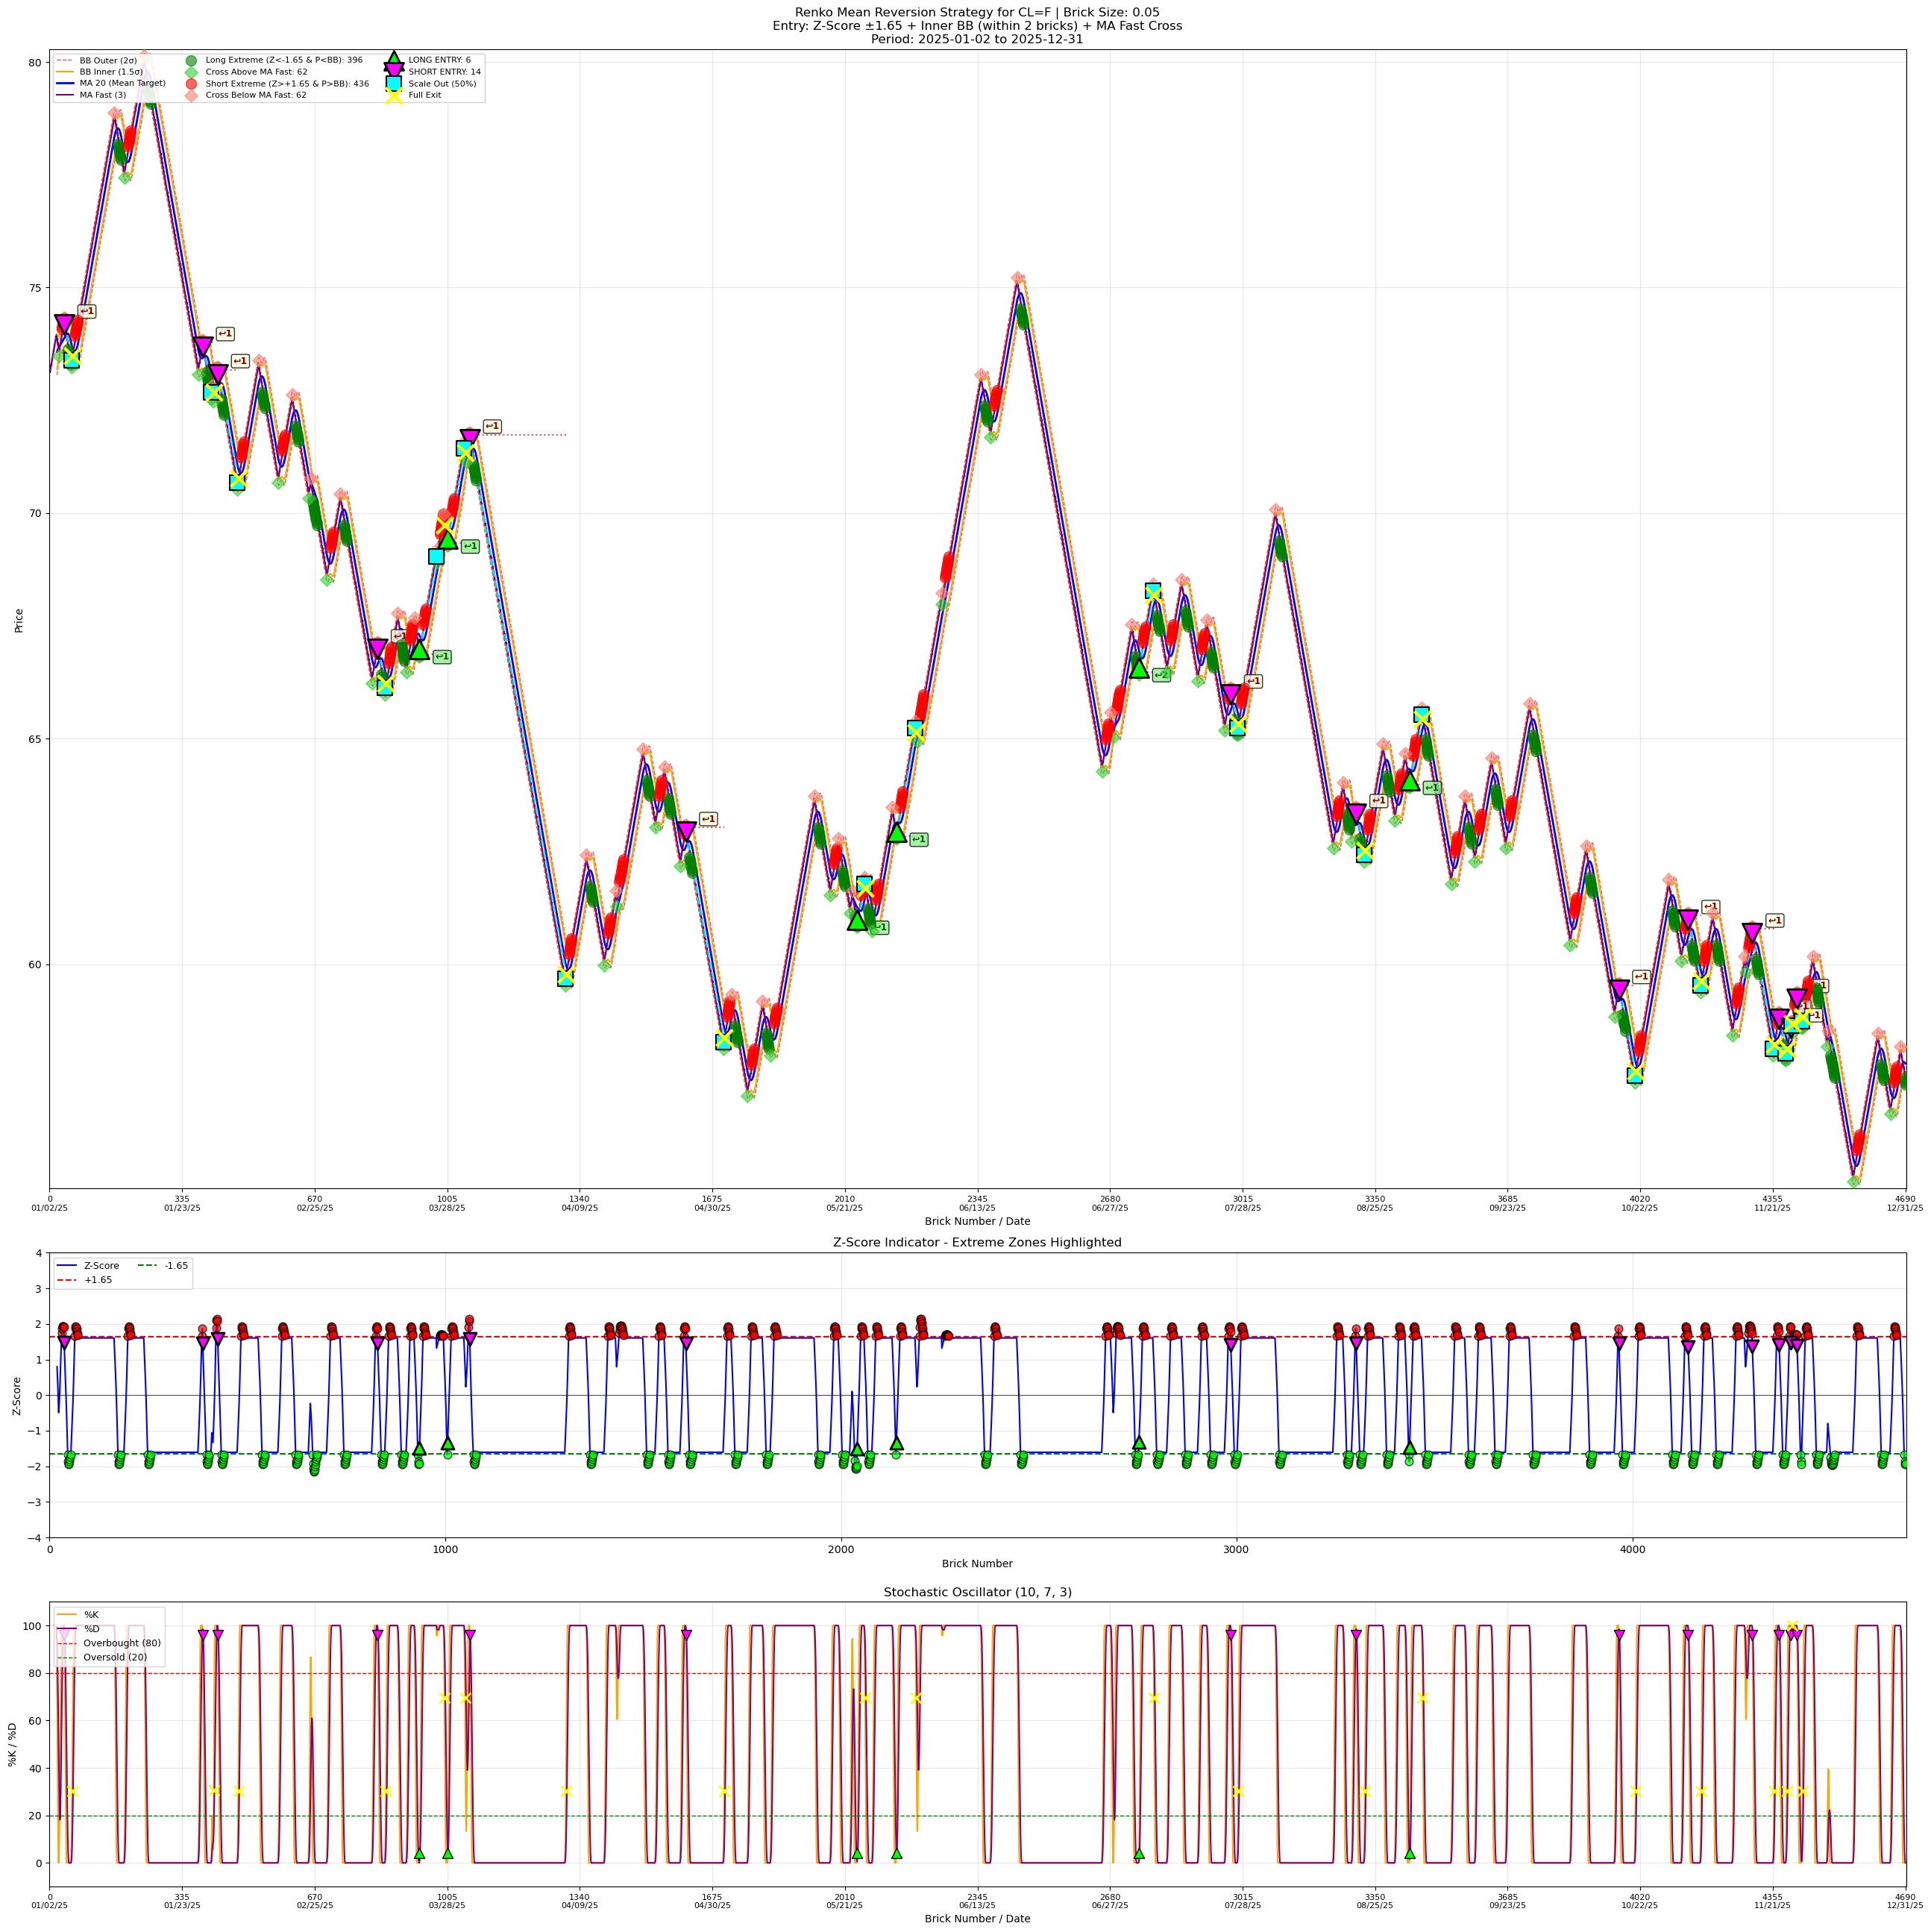

In [9]:
# Debug: Analyze entry conditions with lookback

print("=" * 80)
print("        DEBUG: Entry Conditions Analysis WITH LOOKBACK")
print("=" * 80)
print(f"Lookback Period: {ENTRY_LOOKBACK} bricks (checking current + {ENTRY_LOOKBACK} previous)")
print("-" * 80)

# Filter data where indicators are available
valid_data = renko_df.dropna(subset=['Z_Score', 'BB_Lower_Inner', 'BB_Upper_Inner', 'MA_Fast']).copy()

# --- LONG ENTRY CONDITIONS ---
print("\n--- LONG ENTRY CONDITIONS ---")

# Condition 1 & 2 combined: Z-Score < -1.65 AND Price < Inner Lower BB
long_extreme = valid_data[
    (valid_data['Z_Score'] < -Z_SCORE_EXTREME_THRESHOLD) & 
    (valid_data['Price'] < valid_data['BB_Lower_Inner'])
].index.tolist()
print(f"Bricks with Z-Score < -{Z_SCORE_EXTREME_THRESHOLD} AND Price < Inner BB: {len(long_extreme)}")

# Condition 3: Price crosses above MA Fast
valid_data['Cross_Above_MA_Fast'] = (valid_data['Price_prev'] < valid_data['MA_Fast_prev']) & (valid_data['Price'] > valid_data['MA_Fast'])
long_cross = valid_data[valid_data['Cross_Above_MA_Fast'] == True].index.tolist()
print(f"Bricks with Price crossing above MA Fast: {len(long_cross)}")

# Check for entries WITH LOOKBACK
long_entries_with_lookback = []
for cross_idx in long_cross:
    for lookback in range(ENTRY_LOOKBACK + 1):
        check_idx = cross_idx - lookback
        if check_idx in long_extreme:
            long_entries_with_lookback.append({
                'Cross_Brick': cross_idx,
                'Condition_Brick': check_idx,
                'Lookback': lookback,
                'Cross_Date': renko_df.loc[cross_idx, 'Date'],
                'Z_Score': renko_df.loc[check_idx, 'Z_Score'],
                'Price_at_Cross': renko_df.loc[cross_idx, 'Price']
            })
            break  # Only count once per crossover

print(f"Potential LONG entries with lookback: {len(long_entries_with_lookback)}")

if long_entries_with_lookback:
    print("\nLong Entry Candidates:")
    long_entry_df = pd.DataFrame(long_entries_with_lookback)
    long_entry_df['Cross_Date'] = pd.to_datetime(long_entry_df['Cross_Date']).dt.strftime('%Y-%m-%d')
    display(long_entry_df)

# --- SHORT ENTRY CONDITIONS ---
print("\n--- SHORT ENTRY CONDITIONS ---")

# Condition 1 & 2 combined: Z-Score > +1.65 AND Price > Inner Upper BB
short_extreme = valid_data[
    (valid_data['Z_Score'] > Z_SCORE_EXTREME_THRESHOLD) & 
    (valid_data['Price'] > valid_data['BB_Upper_Inner'])
].index.tolist()
print(f"Bricks with Z-Score > +{Z_SCORE_EXTREME_THRESHOLD} AND Price > Inner BB: {len(short_extreme)}")

# Condition 3: Price crosses below MA Fast
valid_data['Cross_Below_MA_Fast'] = (valid_data['Price_prev'] > valid_data['MA_Fast_prev']) & (valid_data['Price'] < valid_data['MA_Fast'])
short_cross = valid_data[valid_data['Cross_Below_MA_Fast'] == True].index.tolist()
print(f"Bricks with Price crossing below MA Fast: {len(short_cross)}")

# Check for entries WITH LOOKBACK
short_entries_with_lookback = []
for cross_idx in short_cross:
    for lookback in range(ENTRY_LOOKBACK + 1):
        check_idx = cross_idx - lookback
        if check_idx in short_extreme:
            short_entries_with_lookback.append({
                'Cross_Brick': cross_idx,
                'Condition_Brick': check_idx,
                'Lookback': lookback,
                'Cross_Date': renko_df.loc[cross_idx, 'Date'],
                'Z_Score': renko_df.loc[check_idx, 'Z_Score'],
                'Price_at_Cross': renko_df.loc[cross_idx, 'Price']
            })
            break

print(f"Potential SHORT entries with lookback: {len(short_entries_with_lookback)}")

if short_entries_with_lookback:
    print("\nShort Entry Candidates:")
    short_entry_df = pd.DataFrame(short_entries_with_lookback)
    short_entry_df['Cross_Date'] = pd.to_datetime(short_entry_df['Cross_Date']).dt.strftime('%Y-%m-%d')
    display(short_entry_df)

# --- NEAR MISSES ANALYSIS ---
print("\n" + "=" * 80)
print("                    NEAR MISS ANALYSIS")
print("=" * 80)

# Check crossovers that were close to extreme conditions but outside lookback
long_near_misses = []
for cross_idx in long_cross:
    # Check if there was an extreme condition within 5 bricks (beyond lookback)
    for lookback in range(ENTRY_LOOKBACK + 1, 6):
        check_idx = cross_idx - lookback
        if check_idx in long_extreme:
            long_near_misses.append({
                'Cross_Brick': cross_idx,
                'Condition_Brick': check_idx,
                'Missed_By': lookback - ENTRY_LOOKBACK,
                'Cross_Date': renko_df.loc[cross_idx, 'Date']
            })
            break

print(f"\nLong Near Misses (extreme condition {ENTRY_LOOKBACK+1}-5 bricks before crossover): {len(long_near_misses)}")
if long_near_misses:
    display(pd.DataFrame(long_near_misses).head(10))

short_near_misses = []
for cross_idx in short_cross:
    for lookback in range(ENTRY_LOOKBACK + 1, 6):
        check_idx = cross_idx - lookback
        if check_idx in short_extreme:
            short_near_misses.append({
                'Cross_Brick': cross_idx,
                'Condition_Brick': check_idx,
                'Missed_By': lookback - ENTRY_LOOKBACK,
                'Cross_Date': renko_df.loc[cross_idx, 'Date']
            })
            break

print(f"\nShort Near Misses (extreme condition {ENTRY_LOOKBACK+1}-5 bricks before crossover): {len(short_near_misses)}")
if short_near_misses:
    display(pd.DataFrame(short_near_misses).head(10))

print("\n" + "=" * 80)




# ========== CALCULATE DEBUG CONDITIONS WITH LOOKBACK ==========

valid_data = renko_df.dropna(subset=['Z_Score', 'BB_Lower_Inner', 'BB_Upper_Inner', 'MA_Fast']).copy()

# --- EXTREME CONDITIONS (Z-Score + BB combined) ---
long_extreme_cond = valid_data[
    (valid_data['Z_Score'] < -Z_SCORE_EXTREME_THRESHOLD) & 
    (valid_data['Price'] < valid_data['BB_Lower_Inner'])
].index.tolist()

short_extreme_cond = valid_data[
    (valid_data['Z_Score'] > Z_SCORE_EXTREME_THRESHOLD) & 
    (valid_data['Price'] > valid_data['BB_Upper_Inner'])
].index.tolist()

# --- CROSSOVER CONDITIONS ---
valid_data['Cross_Above_MA_Fast'] = (valid_data['Price_prev'] < valid_data['MA_Fast_prev']) & (valid_data['Price'] > valid_data['MA_Fast'])
valid_data['Cross_Below_MA_Fast'] = (valid_data['Price_prev'] > valid_data['MA_Fast_prev']) & (valid_data['Price'] < valid_data['MA_Fast'])

long_cross = valid_data[valid_data['Cross_Above_MA_Fast'] == True].index.tolist()
short_cross = valid_data[valid_data['Cross_Below_MA_Fast'] == True].index.tolist()

# --- POTENTIAL ENTRIES WITH LOOKBACK ---
long_potential_entries = []
for cross_idx in long_cross:
    for lookback in range(ENTRY_LOOKBACK + 1):
        check_idx = cross_idx - lookback
        if check_idx in long_extreme_cond:
            long_potential_entries.append({
                'entry_brick': cross_idx,
                'condition_brick': check_idx,
                'lookback': lookback
            })
            break

short_potential_entries = []
for cross_idx in short_cross:
    for lookback in range(ENTRY_LOOKBACK + 1):
        check_idx = cross_idx - lookback
        if check_idx in short_extreme_cond:
            short_potential_entries.append({
                'entry_brick': cross_idx,
                'condition_brick': check_idx,
                'lookback': lookback
            })
            break

print("=" * 70)
print("                    DEBUG: CONDITIONS SUMMARY")
print("=" * 70)
print(f"\n--- LONG ---")
print(f"Extreme conditions (Z < -{Z_SCORE_EXTREME_THRESHOLD} AND Price < Inner BB): {len(long_extreme_cond)}")
print(f"MA Fast crossovers (up): {len(long_cross)}")
print(f"Potential entries (with {ENTRY_LOOKBACK}-brick lookback): {len(long_potential_entries)}")

print(f"\n--- SHORT ---")
print(f"Extreme conditions (Z > +{Z_SCORE_EXTREME_THRESHOLD} AND Price > Inner BB): {len(short_extreme_cond)}")
print(f"MA Fast crossovers (down): {len(short_cross)}")
print(f"Potential entries (with {ENTRY_LOOKBACK}-brick lookback): {len(short_potential_entries)}")
print("=" * 70)

# ========== SETUP THE PLOT ==========

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(26, 26), gridspec_kw={'height_ratios': [4, 1, 1]})

# ------------------------------------
# Subplot 1: Renko Chart with Debug Markers
# ------------------------------------

ax1.set_title(f"Renko Mean Reversion Strategy for {ticker} | Brick Size: {brick_size}\n"
              f"Entry: Z-Score ±{Z_SCORE_EXTREME_THRESHOLD} + Inner BB (within {ENTRY_LOOKBACK} bricks) + MA Fast Cross\n"
              f"Period: {renko_df['Date'].min().strftime('%Y-%m-%d')} to {renko_df['Date'].max().strftime('%Y-%m-%d')}",
              fontsize=12)
ax1.set_xlabel('Brick Number / Date')
ax1.set_ylabel('Price')

# Plot each brick
for i in range(len(x_positions)):
    color = 'green' if directions[i] == 1 else 'red'
    rect = Rectangle(
        (x_positions[i], y_positions[i]), 1, brick_size,
        facecolor=color, edgecolor='black'
    )
    ax1.add_patch(rect)

# Plot Bollinger Bands
ax1.plot(x_positions, renko_df['BB_Upper_Outer'].tolist(), color='red', linewidth=1, linestyle='--', label='BB Outer (2σ)', alpha=0.7)
ax1.plot(x_positions, renko_df['BB_Lower_Outer'].tolist(), color='red', linewidth=1, linestyle='--', alpha=0.7)
ax1.plot(x_positions, renko_df['BB_Upper_Inner'].tolist(), color='orange', linewidth=1.5, label='BB Inner (1.5σ)')
ax1.plot(x_positions, renko_df['BB_Lower_Inner'].tolist(), color='orange', linewidth=1.5)

# Plot Moving Averages
ax1.plot(x_positions, renko_df['BB_Middle_Outer'].tolist(), color='blue', linewidth=2, label='MA 20 (Mean Target)')
ax1.plot(x_positions, renko_df['MA_Fast'].tolist(), color='purple', linewidth=1.5, label='MA Fast (3)')

# ========== DEBUG MARKERS ==========

# LONG Extreme Condition (Z-Score + BB combined) - Green Circle
if long_extreme_cond:
    ax1.scatter(
        [x_positions[i] for i in long_extreme_cond],
        [renko_df.loc[i, 'Price'] - brick_size * 2 for i in long_extreme_cond],
        marker='o', color='green', s=100, alpha=0.6,
        label=f'Long Extreme (Z<-{Z_SCORE_EXTREME_THRESHOLD} & P<BB): {len(long_extreme_cond)}', zorder=4
    )

# LONG MA Cross Up - Green Diamond
if long_cross:
    ax1.scatter(
        [x_positions[i] for i in long_cross],
        [renko_df.loc[i, 'Price'] - brick_size * 3 for i in long_cross],
        marker='D', color='limegreen', s=80, alpha=0.6,
        label=f'Cross Above MA Fast: {len(long_cross)}', zorder=4
    )

# SHORT Extreme Condition (Z-Score + BB combined) - Red Circle
if short_extreme_cond:
    ax1.scatter(
        [x_positions[i] for i in short_extreme_cond],
        [renko_df.loc[i, 'Price'] + brick_size * 2 for i in short_extreme_cond],
        marker='o', color='red', s=100, alpha=0.6,
        label=f'Short Extreme (Z>+{Z_SCORE_EXTREME_THRESHOLD} & P>BB): {len(short_extreme_cond)}', zorder=4
    )

# SHORT MA Cross Down - Red Diamond
if short_cross:
    ax1.scatter(
        [x_positions[i] for i in short_cross],
        [renko_df.loc[i, 'Price'] + brick_size * 3 for i in short_cross],
        marker='D', color='salmon', s=80, alpha=0.6,
        label=f'Cross Below MA Fast: {len(short_cross)}', zorder=4
    )

# Draw connection lines for LOOKBACK matches (potential entries)
for entry in long_potential_entries:
    if entry['lookback'] > 0:  # Only draw if lookback was used
        ax1.plot(
            [x_positions[entry['condition_brick']], x_positions[entry['entry_brick']]],
            [renko_df.loc[entry['condition_brick'], 'Price'] - brick_size * 2, 
             renko_df.loc[entry['entry_brick'], 'Price'] - brick_size * 3],
            color='lime', linestyle=':', linewidth=2, alpha=0.8
        )

for entry in short_potential_entries:
    if entry['lookback'] > 0:
        ax1.plot(
            [x_positions[entry['condition_brick']], x_positions[entry['entry_brick']]],
            [renko_df.loc[entry['condition_brick'], 'Price'] + brick_size * 2, 
             renko_df.loc[entry['entry_brick'], 'Price'] + brick_size * 3],
            color='magenta', linestyle=':', linewidth=2, alpha=0.8
        )

# ========== TRADE MARKERS (Actual Trades) ==========

# Plot Long Entry Points
long_entries = [t for t in trade_log if t['Type'] == 'LONG']
long_entry_bricks = [t['Entry_Brick'] for t in long_entries]
long_entry_prices = [t['Entry_Price'] for t in long_entries]

if long_entry_bricks:
    ax1.scatter(long_entry_bricks, long_entry_prices, marker='^', color='lime', s=350,
                edgecolors='black', linewidths=2, label=f'LONG ENTRY: {len(long_entry_bricks)}', zorder=7)
    
    # Draw lookback indicator for each entry
    for trade in long_entries:
        if trade.get('Lookback_Used', 0) > 0:
            ax1.annotate(
                f"↩{trade['Lookback_Used']}",
                (trade['Entry_Brick'], trade['Entry_Price']),
                textcoords="offset points", xytext=(15, -10),
                fontsize=9, color='darkgreen', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='lightgreen', alpha=0.8)
            )

# Plot Short Entry Points
short_entries = [t for t in trade_log if t['Type'] == 'SHORT']
short_entry_bricks = [t['Entry_Brick'] for t in short_entries]
short_entry_prices = [t['Entry_Price'] for t in short_entries]

if short_entry_bricks:
    ax1.scatter(short_entry_bricks, short_entry_prices, marker='v', color='magenta', s=350,
                edgecolors='black', linewidths=2, label=f'SHORT ENTRY: {len(short_entry_bricks)}', zorder=7)
    
    # Draw lookback indicator for each entry
    for trade in short_entries:
        if trade.get('Lookback_Used', 0) > 0:
            ax1.annotate(
                f"↩{trade['Lookback_Used']}",
                (trade['Entry_Brick'], trade['Entry_Price']),
                textcoords="offset points", xytext=(15, 10),
                fontsize=9, color='darkred', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow', alpha=0.8)
            )

# Plot Scale Out Points
scale_out_bricks = [t['Scale_Out_Brick'] for t in trade_log if 'Scale_Out_Brick' in t]
scale_out_prices = [t['Scale_Out_Price'] for t in trade_log if 'Scale_Out_Price' in t]

if scale_out_bricks:
    ax1.scatter(scale_out_bricks, scale_out_prices, marker='s', color='cyan', s=200,
                edgecolors='black', linewidths=1.5, label='Scale Out (50%)', zorder=7)

# Plot Exit Points
exit_bricks = [t['Exit_Brick'] for t in trade_log if 'Exit_Brick' in t]
exit_prices = [t['Exit_Price'] for t in trade_log if 'Exit_Price' in t]

if exit_bricks:
    ax1.scatter(exit_bricks, exit_prices, marker='x', color='yellow', s=250,
                linewidths=3, label='Full Exit', zorder=7)

# Plot Stop Loss Lines
for trade in trade_log:
    if 'Stop_Loss' in trade:
        entry_brick = trade['Entry_Brick']
        exit_brick = trade.get('Exit_Brick', entry_brick + 20)
        stop_loss = trade['Stop_Loss']
        ax1.plot([entry_brick, exit_brick], [stop_loss, stop_loss], 
                 color='red', linestyle=':', linewidth=1.5, alpha=0.7)

# Draw lines connecting entry to exit
for trade in trade_log:
    if 'Exit_Brick' in trade:
        pnl = trade.get('PnL', 0)
        line_color = 'cyan' if pnl > 0 else 'orange'
        ax1.plot([trade['Entry_Brick'], trade['Exit_Brick']],
                 [trade['Entry_Price'], trade['Exit_Price']],
                 color=line_color, linestyle='--', linewidth=2, alpha=0.8)

# Set axis limits
ax1.set_xlim(-1, max(x_positions) + 2)
ax1.set_ylim(min(y_positions) - brick_size * 5, max(y_positions) + brick_size * 5)

# X-axis with dates
num_ticks = 15
tick_indices = np.linspace(0, len(x_positions) - 1, num_ticks, dtype=int)
tick_labels = [f"{x_positions[i]}\n{renko_df.loc[i, 'Date'].strftime('%m/%d/%y')}" for i in tick_indices]
ax1.set_xticks([x_positions[i] for i in tick_indices])
ax1.set_xticklabels(tick_labels, fontsize=8)

ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left', fontsize=8, ncol=3, framealpha=0.9)

# ------------------------------------
# Subplot 2: Z-Score with Extreme Zones
# ------------------------------------

ax2.set_title("Z-Score Indicator - Extreme Zones Highlighted", fontsize=12)
ax2.set_xlabel('Brick Number')
ax2.set_ylabel('Z-Score')

ax2.plot(x_positions, renko_df['Z_Score'].tolist(), label='Z-Score', color='blue', linewidth=1.5)
ax2.axhline(Z_SCORE_EXTREME_THRESHOLD, color='red', linestyle='--', linewidth=1.5, label=f'+{Z_SCORE_EXTREME_THRESHOLD}')
ax2.axhline(-Z_SCORE_EXTREME_THRESHOLD, color='green', linestyle='--', linewidth=1.5, label=f'-{Z_SCORE_EXTREME_THRESHOLD}')
ax2.axhline(0, color='black', linestyle='-', linewidth=0.5)

# Fill extreme zones
z_scores = renko_df['Z_Score'].tolist()
ax2.fill_between(x_positions, Z_SCORE_EXTREME_THRESHOLD, z_scores, 
                  where=[z > Z_SCORE_EXTREME_THRESHOLD if not pd.isna(z) else False for z in z_scores], 
                  color='red', alpha=0.3)
ax2.fill_between(x_positions, -Z_SCORE_EXTREME_THRESHOLD, z_scores, 
                  where=[z < -Z_SCORE_EXTREME_THRESHOLD if not pd.isna(z) else False for z in z_scores], 
                  color='green', alpha=0.3)

# Mark extreme + BB conditions (combined)
if long_extreme_cond:
    ax2.scatter([x_positions[i] for i in long_extreme_cond],
                [renko_df.loc[i, 'Z_Score'] for i in long_extreme_cond],
                marker='o', color='lime', s=60, edgecolors='black', alpha=0.7, zorder=4)

if short_extreme_cond:
    ax2.scatter([x_positions[i] for i in short_extreme_cond],
                [renko_df.loc[i, 'Z_Score'] for i in short_extreme_cond],
                marker='o', color='red', s=60, edgecolors='black', alpha=0.7, zorder=4)

# Mark actual entries
if long_entry_bricks:
    ax2.scatter(long_entry_bricks, [renko_df.loc[i, 'Z_Score'] for i in long_entry_bricks],
                marker='^', color='lime', s=150, edgecolors='black', linewidths=2, zorder=5)

if short_entry_bricks:
    ax2.scatter(short_entry_bricks, [renko_df.loc[i, 'Z_Score'] for i in short_entry_bricks],
                marker='v', color='magenta', s=150, edgecolors='black', linewidths=2, zorder=5)

ax2.set_xlim(-1, max(x_positions) + 2)
ax2.set_ylim(-4, 4)
ax2.legend(loc='upper left', fontsize=9, ncol=2)
ax2.grid(True, alpha=0.3)

# ------------------------------------
# Subplot 3: Stochastic Oscillator
# ------------------------------------

ax3.set_title(f"Stochastic Oscillator ({STOCHASTIC_K_PERIOD}, {STOCHASTIC_D_PERIOD}, {STOCHASTIC_SMOOTHING_PERIOD})", fontsize=12)
ax3.set_xlabel('Brick Number / Date')
ax3.set_ylabel('%K / %D')

ax3.plot(x_positions, renko_df['%K'].tolist(), label='%K', color='orange', linewidth=1.5)
ax3.plot(x_positions, renko_df['%D'].tolist(), label='%D', color='purple', linewidth=1.5)

ax3.axhline(STOCHASTIC_EXIT_LEVEL_SHORT, color='red', linestyle='--', linewidth=1, label=f'Overbought ({STOCHASTIC_EXIT_LEVEL_SHORT})')
ax3.axhline(STOCHASTIC_EXIT_LEVEL_LONG, color='green', linestyle='--', linewidth=1, label=f'Oversold ({STOCHASTIC_EXIT_LEVEL_LONG})')

if long_entry_bricks:
    ax3.scatter(long_entry_bricks, [renko_df.loc[i, '%K'] for i in long_entry_bricks],
                marker='^', color='lime', s=100, edgecolors='black', zorder=5)

if short_entry_bricks:
    ax3.scatter(short_entry_bricks, [renko_df.loc[i, '%K'] for i in short_entry_bricks],
                marker='v', color='magenta', s=100, edgecolors='black', zorder=5)

if exit_bricks:
    ax3.scatter(exit_bricks, [renko_df.loc[i, '%K'] for i in exit_bricks],
                marker='x', color='yellow', s=100, linewidths=2, zorder=5)

ax3.set_xlim(-1, max(x_positions) + 2)
ax3.set_ylim(-10, 110)
ax3.set_xticks([x_positions[i] for i in tick_indices])
ax3.set_xticklabels(tick_labels, fontsize=8)
ax3.legend(loc='upper left', fontsize=9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

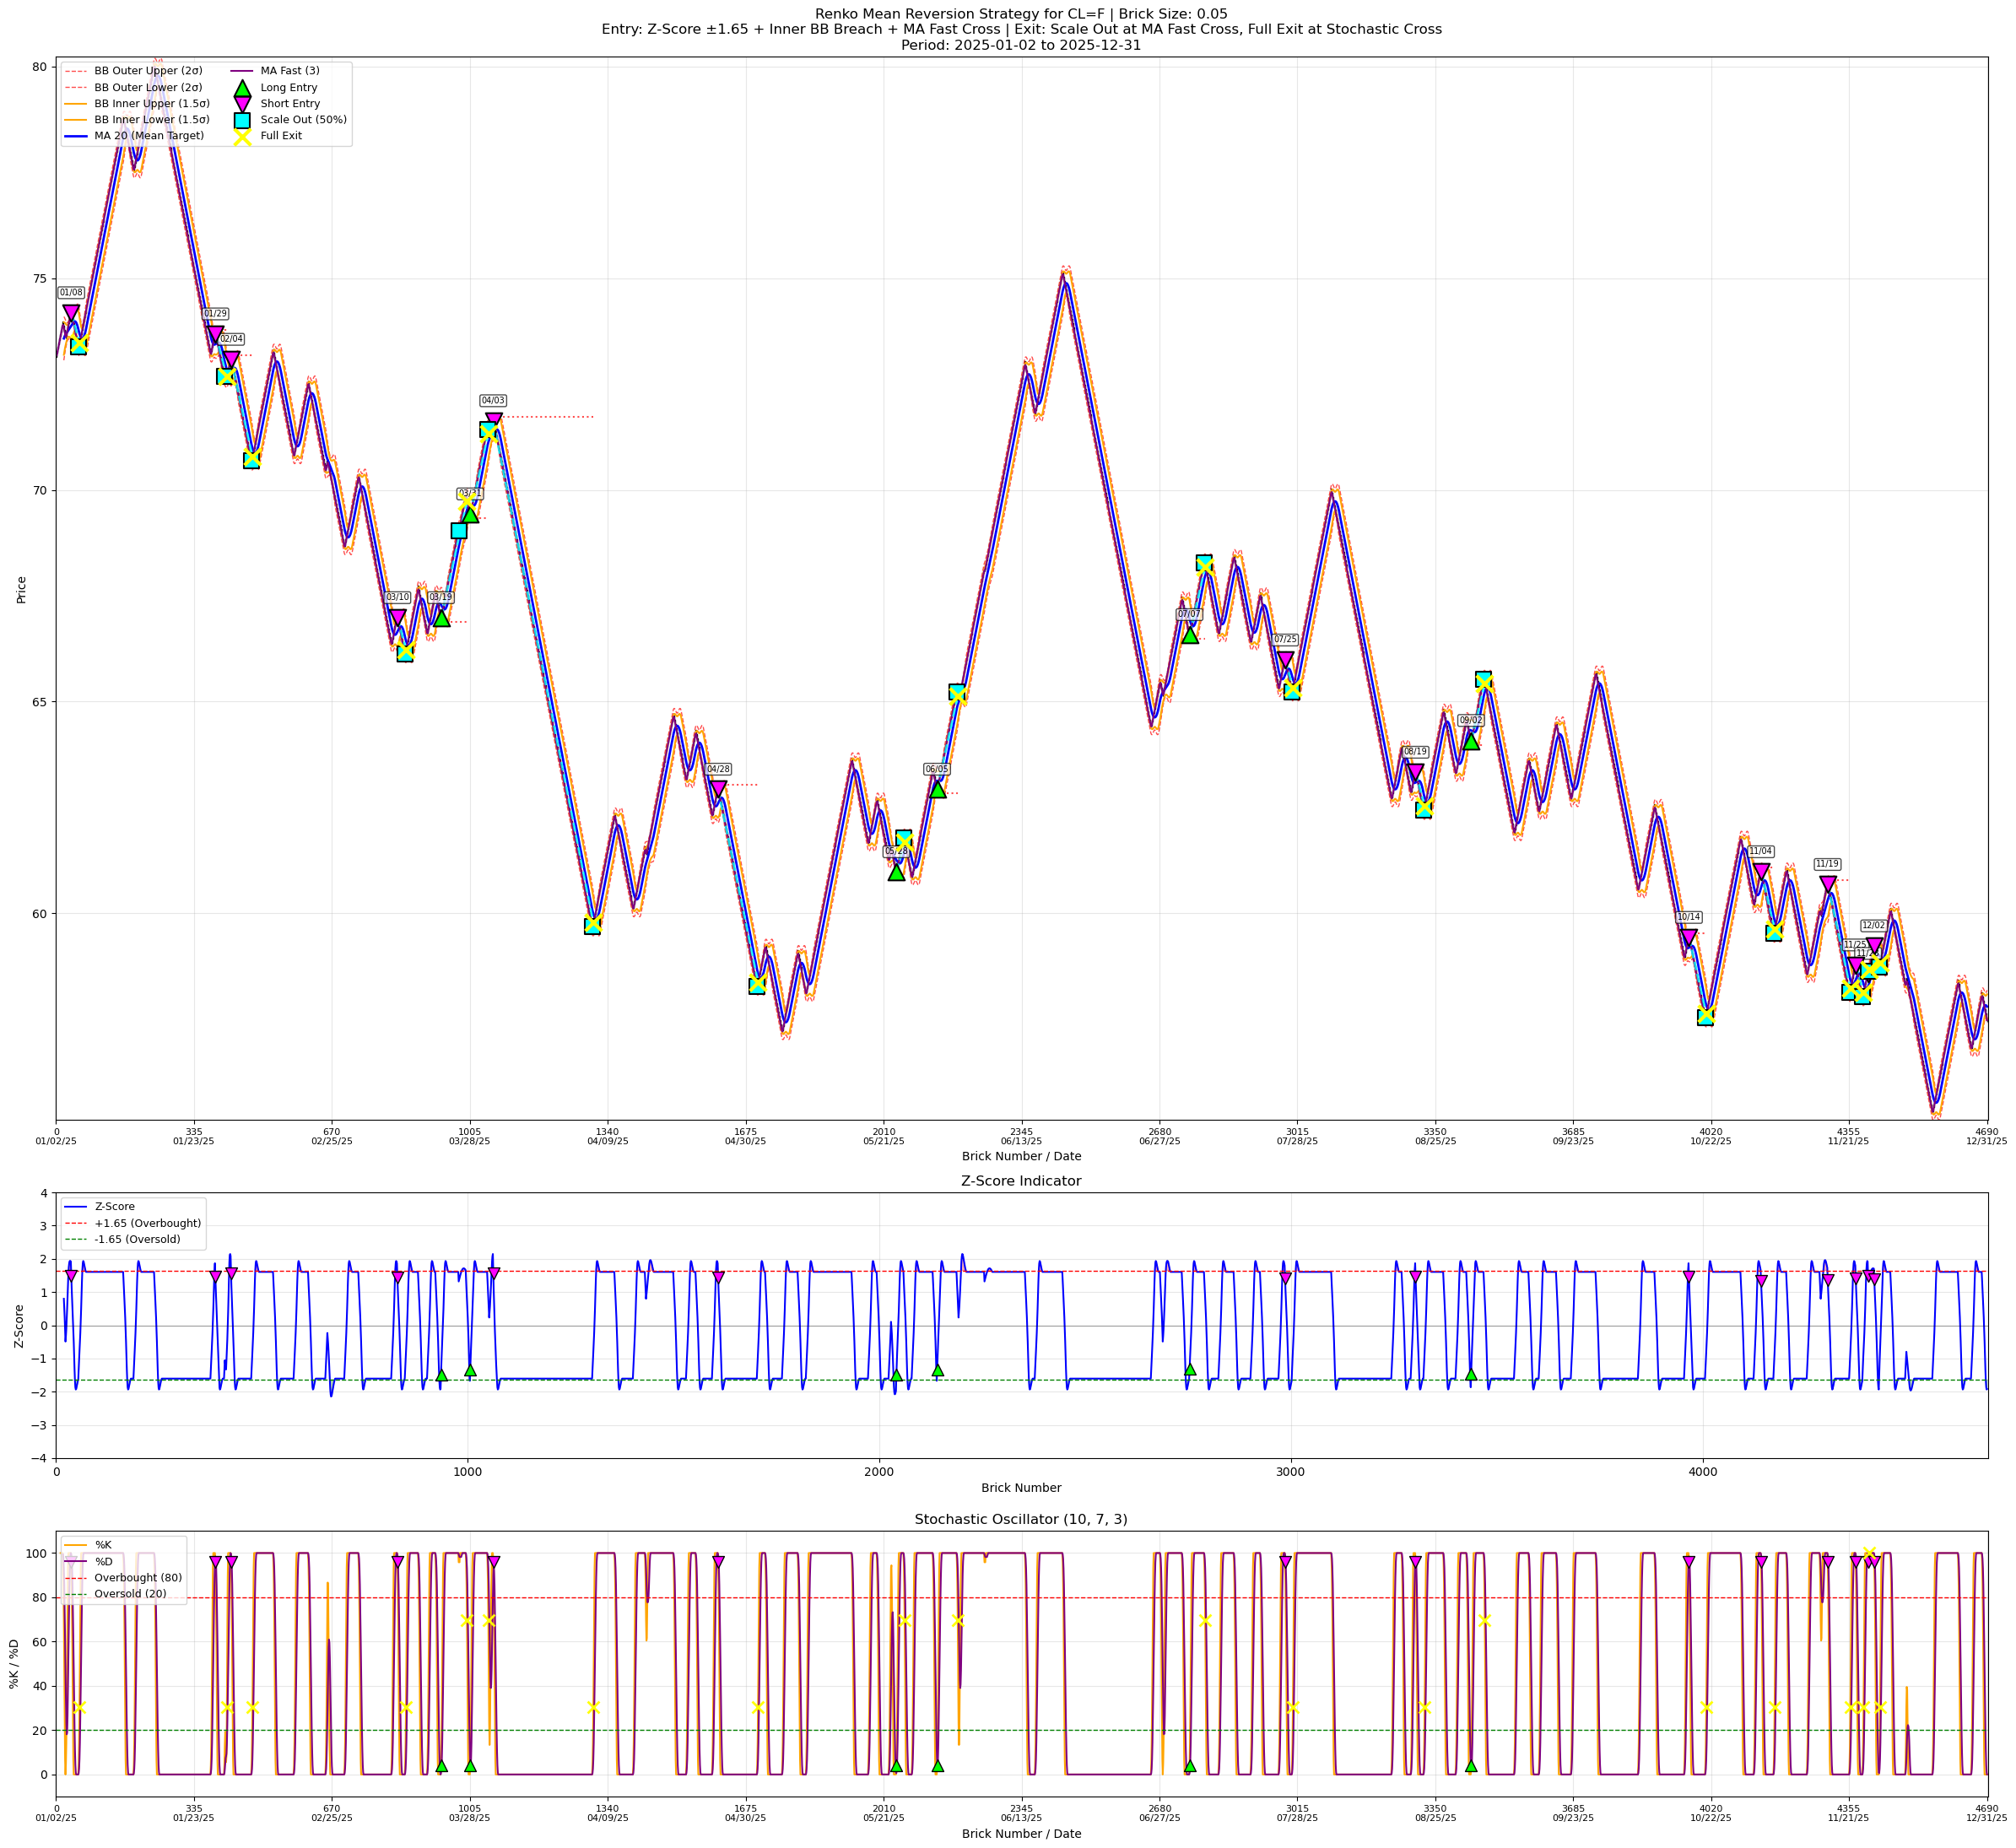

In [10]:
# Setup the plot with three subplots: Renko, Z-Score, and Stochastic
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(24, 22), gridspec_kw={'height_ratios': [4, 1, 1]})

# ------------------------------------
# Subplot 1: Renko Chart with Bollinger Bands and Trades
# ------------------------------------

ax1.set_title(f"Renko Mean Reversion Strategy for {ticker} | Brick Size: {brick_size}\n"
              f"Entry: Z-Score ±{Z_SCORE_EXTREME_THRESHOLD} + Inner BB Breach + MA Fast Cross | "
              f"Exit: Scale Out at MA Fast Cross, Full Exit at Stochastic Cross\n"
              f"Period: {renko_df['Date'].min().strftime('%Y-%m-%d')} to {renko_df['Date'].max().strftime('%Y-%m-%d')}",
              fontsize=12)
ax1.set_xlabel('Brick Number / Date')
ax1.set_ylabel('Price')

# Plot each brick
for i in range(len(x_positions)):
    color = 'green' if directions[i] == 1 else 'red'
    rect = Rectangle(
        (x_positions[i], y_positions[i]), 1, brick_size,
        facecolor=color, edgecolor='black'
    )
    ax1.add_patch(rect)

# Plot Bollinger Bands (Outer)
ax1.plot(x_positions, renko_df['BB_Upper_Outer'].tolist(), color='red', linewidth=1, linestyle='--', label='BB Outer Upper (2σ)', alpha=0.7)
ax1.plot(x_positions, renko_df['BB_Lower_Outer'].tolist(), color='red', linewidth=1, linestyle='--', label='BB Outer Lower (2σ)', alpha=0.7)

# Plot Bollinger Bands (Inner)
ax1.plot(x_positions, renko_df['BB_Upper_Inner'].tolist(), color='orange', linewidth=1.5, label='BB Inner Upper (1.5σ)')
ax1.plot(x_positions, renko_df['BB_Lower_Inner'].tolist(), color='orange', linewidth=1.5, label='BB Inner Lower (1.5σ)')

# Plot Moving Averages
ax1.plot(x_positions, renko_df['BB_Middle_Outer'].tolist(), color='blue', linewidth=2, label='MA 20 (Mean Target)')
ax1.plot(x_positions, renko_df['MA_Fast'].tolist(), color='purple', linewidth=1.5, label='MA Fast (3)')

# Plot Long Entry Points
long_entries = [t for t in trade_log if t['Type'] == 'LONG']
long_entry_bricks = [t['Entry_Brick'] for t in long_entries]
long_entry_prices = [t['Entry_Price'] for t in long_entries]

if long_entry_bricks:
    ax1.scatter(long_entry_bricks, long_entry_prices, marker='^', color='lime', s=200,
                edgecolors='black', linewidths=1.5, label='Long Entry', zorder=5)

# Plot Short Entry Points
short_entries = [t for t in trade_log if t['Type'] == 'SHORT']
short_entry_bricks = [t['Entry_Brick'] for t in short_entries]
short_entry_prices = [t['Entry_Price'] for t in short_entries]

if short_entry_bricks:
    ax1.scatter(short_entry_bricks, short_entry_prices, marker='v', color='magenta', s=200,
                edgecolors='black', linewidths=1.5, label='Short Entry', zorder=5)

# Plot Scale Out Points
scale_out_bricks = [t['Scale_Out_Brick'] for t in trade_log if 'Scale_Out_Brick' in t]
scale_out_prices = [t['Scale_Out_Price'] for t in trade_log if 'Scale_Out_Price' in t]

if scale_out_bricks:
    ax1.scatter(scale_out_bricks, scale_out_prices, marker='s', color='cyan', s=150,
                edgecolors='black', linewidths=1.5, label='Scale Out (50%)', zorder=5)

# Plot Exit Points
exit_bricks = [t['Exit_Brick'] for t in trade_log if 'Exit_Brick' in t]
exit_prices = [t['Exit_Price'] for t in trade_log if 'Exit_Price' in t]

if exit_bricks:
    ax1.scatter(exit_bricks, exit_prices, marker='x', color='yellow', s=200,
                linewidths=3, label='Full Exit', zorder=5)

# Plot Stop Loss Lines
for trade in trade_log:
    if 'Stop_Loss' in trade:
        entry_brick = trade['Entry_Brick']
        exit_brick = trade.get('Exit_Brick', entry_brick + 20)
        stop_loss = trade['Stop_Loss']
        ax1.plot([entry_brick, exit_brick], [stop_loss, stop_loss], 
                 color='red', linestyle=':', linewidth=1.5, alpha=0.7)

# Draw lines connecting entry to exit
for trade in trade_log:
    if 'Exit_Brick' in trade:
        pnl = trade.get('PnL', 0)
        line_color = 'cyan' if pnl > 0 else 'orange'
        ax1.plot([trade['Entry_Brick'], trade['Exit_Brick']],
                 [trade['Entry_Price'], trade['Exit_Price']],
                 color=line_color, linestyle='--', linewidth=2, alpha=0.8)

# Add date annotations for trades
for trade in trade_log:
    entry_date = trade.get('Entry_Date')
    if entry_date:
        ax1.annotate(entry_date.strftime('%m/%d'),
                     (trade['Entry_Brick'], trade['Entry_Price']),
                     textcoords="offset points", xytext=(0, 15),
                     fontsize=7, ha='center', color='black',
                     bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

# Set axis limits
ax1.set_xlim(-1, max(x_positions) + 2)
ax1.set_ylim(min(y_positions) - brick_size * 3, max(y_positions) + brick_size * 4)

# X-axis with dates
num_ticks = 15
tick_indices = np.linspace(0, len(x_positions) - 1, num_ticks, dtype=int)
tick_labels = [f"{x_positions[i]}\n{renko_df.loc[i, 'Date'].strftime('%m/%d/%y')}" for i in tick_indices]
ax1.set_xticks([x_positions[i] for i in tick_indices])
ax1.set_xticklabels(tick_labels, fontsize=8)

ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left', fontsize=9, ncol=2)

# ------------------------------------
# Subplot 2: Z-Score
# ------------------------------------

ax2.set_title("Z-Score Indicator", fontsize=12)
ax2.set_xlabel('Brick Number')
ax2.set_ylabel('Z-Score')

ax2.plot(x_positions, renko_df['Z_Score'].tolist(), label='Z-Score', color='blue', linewidth=1.5)
ax2.axhline(Z_SCORE_EXTREME_THRESHOLD, color='red', linestyle='--', linewidth=1, label=f'+{Z_SCORE_EXTREME_THRESHOLD} (Overbought)')
ax2.axhline(-Z_SCORE_EXTREME_THRESHOLD, color='green', linestyle='--', linewidth=1, label=f'-{Z_SCORE_EXTREME_THRESHOLD} (Oversold)')
ax2.axhline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

# Fill extreme zones
ax2.fill_between(x_positions, Z_SCORE_EXTREME_THRESHOLD, renko_df['Z_Score'].tolist(), 
                  where=[z > Z_SCORE_EXTREME_THRESHOLD for z in renko_df['Z_Score']], 
                  color='red', alpha=0.3)
ax2.fill_between(x_positions, -Z_SCORE_EXTREME_THRESHOLD, renko_df['Z_Score'].tolist(), 
                  where=[z < -Z_SCORE_EXTREME_THRESHOLD for z in renko_df['Z_Score']], 
                  color='green', alpha=0.3)

# Mark entry points on Z-Score
if long_entry_bricks:
    ax2.scatter(long_entry_bricks, [renko_df.loc[i, 'Z_Score'] for i in long_entry_bricks],
                marker='^', color='lime', s=100, edgecolors='black', zorder=5)

if short_entry_bricks:
    ax2.scatter(short_entry_bricks, [renko_df.loc[i, 'Z_Score'] for i in short_entry_bricks],
                marker='v', color='magenta', s=100, edgecolors='black', zorder=5)

ax2.set_xlim(-1, max(x_positions) + 2)
ax2.set_ylim(-4, 4)
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)

# ------------------------------------
# Subplot 3: Stochastic Oscillator
# ------------------------------------

ax3.set_title(f"Stochastic Oscillator ({STOCHASTIC_K_PERIOD}, {STOCHASTIC_D_PERIOD}, {STOCHASTIC_SMOOTHING_PERIOD})", fontsize=12)
ax3.set_xlabel('Brick Number / Date')
ax3.set_ylabel('%K / %D')

ax3.plot(x_positions, renko_df['%K'].tolist(), label='%K', color='orange', linewidth=1.5)
ax3.plot(x_positions, renko_df['%D'].tolist(), label='%D', color='purple', linewidth=1.5)

ax3.axhline(STOCHASTIC_EXIT_LEVEL_SHORT, color='red', linestyle='--', linewidth=1, label=f'Overbought ({STOCHASTIC_EXIT_LEVEL_SHORT})')
ax3.axhline(STOCHASTIC_EXIT_LEVEL_LONG, color='green', linestyle='--', linewidth=1, label=f'Oversold ({STOCHASTIC_EXIT_LEVEL_LONG})')

# Mark entry/exit points
if long_entry_bricks:
    ax3.scatter(long_entry_bricks, [renko_df.loc[i, '%K'] for i in long_entry_bricks],
                marker='^', color='lime', s=100, edgecolors='black', zorder=5)

if short_entry_bricks:
    ax3.scatter(short_entry_bricks, [renko_df.loc[i, '%K'] for i in short_entry_bricks],
                marker='v', color='magenta', s=100, edgecolors='black', zorder=5)

if exit_bricks:
    ax3.scatter(exit_bricks, [renko_df.loc[i, '%K'] for i in exit_bricks],
                marker='x', color='yellow', s=100, linewidths=2, zorder=5)

ax3.set_xlim(-1, max(x_positions) + 2)
ax3.set_ylim(-10, 110)
ax3.set_xticks([x_positions[i] for i in tick_indices])
ax3.set_xticklabels(tick_labels, fontsize=8)
ax3.legend(loc='upper left', fontsize=9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Display trade log as DataFrame
if trade_log:
    trade_log_df = pd.DataFrame(trade_log)
    
    # Format dates
    if 'Entry_Date' in trade_log_df.columns:
        trade_log_df['Entry_Date'] = pd.to_datetime(trade_log_df['Entry_Date']).dt.strftime('%Y-%m-%d')
    if 'Exit_Date' in trade_log_df.columns:
        trade_log_df['Exit_Date'] = pd.to_datetime(trade_log_df['Exit_Date']).dt.strftime('%Y-%m-%d')
    if 'Scale_Out_Date' in trade_log_df.columns:
        trade_log_df['Scale_Out_Date'] = pd.to_datetime(trade_log_df['Scale_Out_Date']).dt.strftime('%Y-%m-%d')
    
    # Add profit/loss indicator
    trade_log_df['Result'] = trade_log_df['PnL'].apply(
        lambda x: '✅ WIN' if x > 0 else ('❌ LOSS' if x < 0 else '➖ BE') if pd.notna(x) else '⏳ OPEN'
    )
    
    # Format R:R ratio
    if 'RR_Ratio' in trade_log_df.columns:
        trade_log_df['R:R'] = trade_log_df['RR_Ratio'].apply(lambda x: f"{x:.2f}R" if pd.notna(x) else "N/A")
    
    # Format Z-Score
    if 'Z_Score_Entry' in trade_log_df.columns:
        trade_log_df['Z_Score'] = trade_log_df['Z_Score_Entry'].apply(lambda x: f"{x:.2f}" if pd.notna(x) else "N/A")
    
    # Reorder columns
    cols = ['Type', 'Entry_Date', 'Entry_Brick', 'Entry_Price', 'Z_Score', 'Stop_Loss',
            'Scale_Out_Date', 'Scale_Out_Price', 'Scale_Out_PnL',
            'Exit_Date', 'Exit_Brick', 'Exit_Price', 'Exit_Type',
            'Size', 'PnL', 'R:R', 'Capital', 'Result']
    cols = [c for c in cols if c in trade_log_df.columns]
    trade_log_df = trade_log_df[cols]
    
    display(trade_log_df)
    
    # Summary by trade type
    print("\n" + "=" * 70)
    print("                    TRADE SUMMARY BY TYPE")
    print("=" * 70)
    
    for trade_type in ['LONG', 'SHORT']:
        type_trades = [t for t in trade_log if t['Type'] == trade_type and 'PnL' in t]
        if type_trades:
            type_pnl = sum(t['PnL'] for t in type_trades)
            type_wins = len([t for t in type_trades if t['PnL'] > 0])
            type_losses = len([t for t in type_trades if t['PnL'] < 0])
            type_win_rr = [t['RR_Ratio'] for t in type_trades if t.get('PnL', 0) > 0 and 'RR_Ratio' in t]
            type_loss_rr = [t['RR_Ratio'] for t in type_trades if t.get('PnL', 0) < 0 and 'RR_Ratio' in t]
            
            print(f"\n{trade_type} Trades:")
            print(f"  Total: {len(type_trades)}")
            print(f"  Wins: {type_wins} | Losses: {type_losses}")
            print(f"  Win Rate: {type_wins/len(type_trades)*100:.1f}%" if type_trades else "  Win Rate: N/A")
            print(f"  Total PnL: ${type_pnl:,.2f}")
            print(f"  Avg Winning R:R: {np.mean(type_win_rr):.2f}R" if type_win_rr else "  Avg Winning R:R: N/A")
            print(f"  Avg Losing R:R: {np.mean(type_loss_rr):.2f}R" if type_loss_rr else "  Avg Losing R:R: N/A")
        else:
            print(f"\n{trade_type} Trades: None")
    
    # Exit Type Analysis
    print("\n" + "=" * 70)
    print("                    EXIT TYPE ANALYSIS")
    print("=" * 70)
    
    exit_types = {}
    for trade in trade_log:
        if 'Exit_Type' in trade:
            exit_type = trade['Exit_Type']
            if exit_type not in exit_types:
                exit_types[exit_type] = {'count': 0, 'pnl': 0}
            exit_types[exit_type]['count'] += 1
            exit_types[exit_type]['pnl'] += trade.get('PnL', 0)
    
    for exit_type, stats in exit_types.items():
        print(f"\n{exit_type}:")
        print(f"  Count: {stats['count']}")
        print(f"  Total PnL: ${stats['pnl']:,.2f}")
    
    
else:
    print("No trades executed.")

,Type,Entry_Date,Entry_Brick,Entry_Price,Z_Score,Stop_Loss,Scale_Out_Date,Scale_Out_Price,Scale_Out_PnL,Exit_Date,Exit_Brick,Exit_Price,Exit_Type,Size,PnL,R:R,Capital,Result
0,SHORT,2025-01-08,37,74.179997,1.92,74.279997,2025-01-09,73.379997,400.000000,2025-01-09,57,73.479997,%K CROSSED BACK ABOVE 20,1000.000000,750.000000,7.50R,10750.000000,✅ WIN
1,SHORT,2025-01-29,387,73.679997,1.87,73.779997,2025-01-30,72.679997,537.500000,2025-02-03,415,72.679997,%K CROSSED BACK ABOVE 20,1075.000000,1075.000000,10.00R,11825.000000,✅ WIN
2,SHORT,2025-02-04,425,73.079997,2.09,73.179997,2025-02-07,70.679997,1419.000000,2025-02-07,477,70.779997,%K CROSSED BACK ABOVE 20,1182.500000,2778.875000,23.50R,14603.875000,✅ WIN
3,SHORT,2025-03-10,829,66.979997,1.86,67.079997,2025-03-11,66.129997,620.664687,2025-03-11,850,66.229997,%K CROSSED BACK ABOVE 20,1460.387500,1168.310000,8.00R,15772.185000,✅ WIN
4,LONG,2025-03-19,935,66.979997,-1.92,66.879997,2025-03-25,69.029997,1616.648962,2025-03-28,998,69.729997,%K CROSSED BACK BELOW 80,1577.218500,3785.324400,24.00R,19557.509400,✅ WIN
5,LONG,2025-03-31,1006,69.429997,-1.67,69.329997,2025-04-01,71.429997,1955.750940,2025-04-01,1050,71.329997,%K CROSSED BACK BELOW 80,1955.750940,3813.714333,19.50R,23371.223733,✅ WIN
6,SHORT,2025-04-03,1062,71.629997,2.14,71.729997,2025-04-09,59.679997,13964.306180,2025-04-09,1305,59.779997,%K CROSSED BACK ABOVE 20,2337.122373,27811.756242,119.00R,51182.979975,✅ WIN
7,SHORT,2025-04-28,1608,62.929997,1.86,63.029997,2025-05-01,58.279997,11900.042844,2025-05-01,1705,58.379997,%K CROSSED BACK ABOVE 20,5118.297998,23544.170789,46.00R,74727.150764,✅ WIN
8,LONG,2025-05-28,2041,60.979997,-1.98,60.879997,2025-05-29,61.779997,2989.086031,2025-05-29,2061,61.679997,%K CROSSED BACK BELOW 80,7472.715076,5604.536307,7.50R,80331.687071,✅ WIN
9,LONG,2025-06-05,2140,62.929997,-1.67,62.829997,2025-06-10,65.229997,9238.144013,2025-06-10,2190,65.129997,%K CROSSED BACK BELOW 80,8033.168707,18074.629591,22.50R,98406.316662,✅ WIN



                    TRADE SUMMARY BY TYPE

LONG Trades:
  Total: 6
  Wins: 6 | Losses: 0
  Win Rate: 100.0%
  Total PnL: $66,148.58
  Avg Winning R:R: 17.33R
  Avg Losing R:R: N/A

SHORT Trades:
  Total: 14
  Wins: 13 | Losses: 1
  Win Rate: 92.9%
  Total PnL: $208,186.91
  Avg Winning R:R: 22.96R
  Avg Losing R:R: -0.50R

                    EXIT TYPE ANALYSIS

%K CROSSED BACK ABOVE 20:
  Count: 13
  Total PnL: $210,243.02

%K CROSSED BACK BELOW 80:
  Count: 6
  Total PnL: $66,148.58

STOP LOSS:
  Count: 1
  Total PnL: $-2,056.11


      STRATEGY PERFORMANCE METRICS (FULL DATASET)
Initial Capital:        $10,000.00
Final Capital:          $284,335.49
Total Return:           2743.35%
Sharpe Ratio:           0.97
Max Drawdown:           -0.75%
------------------------------------------------------------
Total Trades:           20
  - Long Trades:        6
  - Short Trades:       14
------------------------------------------------------------
Overall Win Rate:       95.00%
Long Win Rate:          100.00%
Short Win Rate:         92.86%
Profit Factor:          134.42
------------------------------------------------------------
Average Win:            $14,546.93
Average Loss:           $-2,056.11
------------------------------------------------------------
              STREAK ANALYSIS
------------------------------------------------------------
Max Winning Streak:     18 trades
Max Losing Streak:      1 trades
------------------------------------------------------------
            RISK-REWARD ANALYSIS
---------------

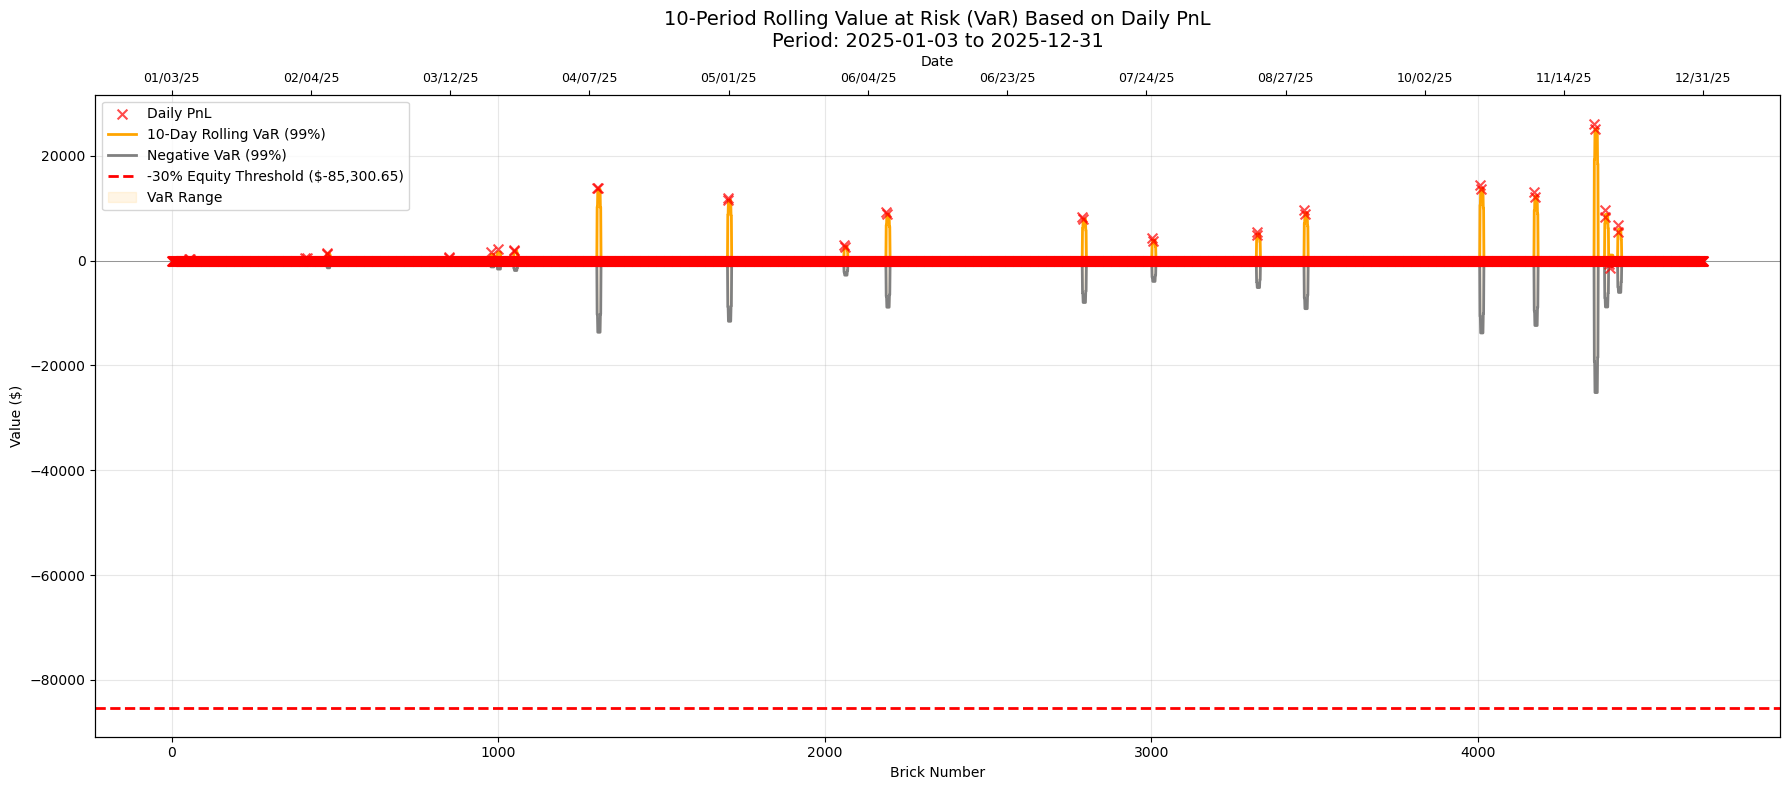

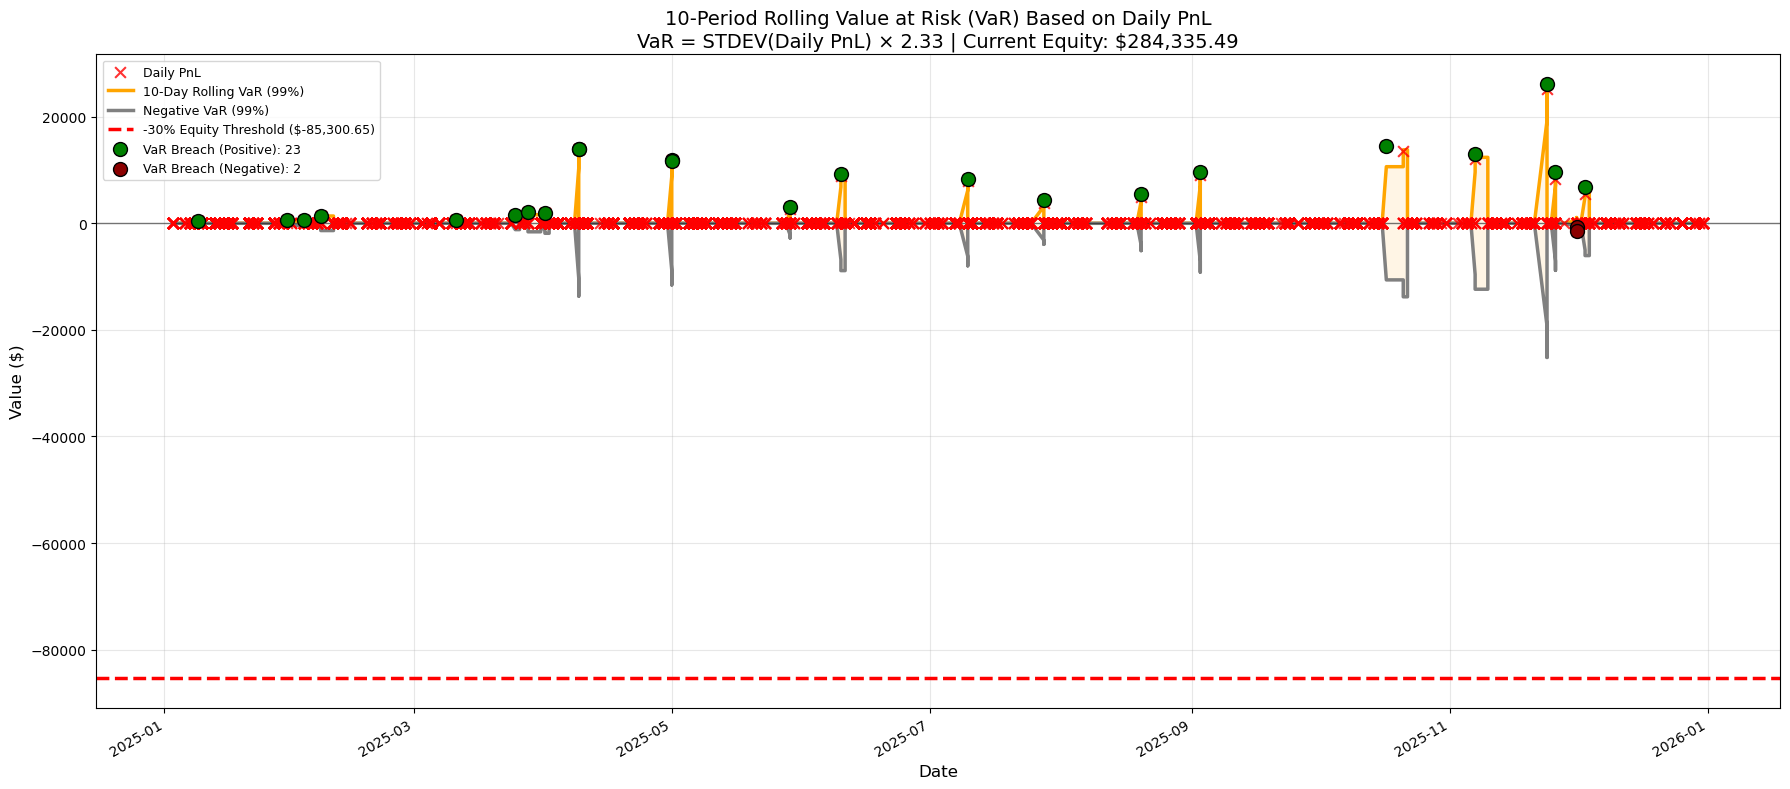


           VaR BREACH ANALYSIS
Total Daily PnL Observations:  4690
VaR Breaches (Positive):       23
VaR Breaches (Negative):       2
Breach Rate:                   0.53%
Expected Breach Rate (99%):    1.00%


/var/folders/2v/mkg1tcnj0dsgbn4wspnx8l0h0000gn/T/ipykernel_97419/82645235.py:361: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(box_data, labels=box_labels, patch_artist=True)


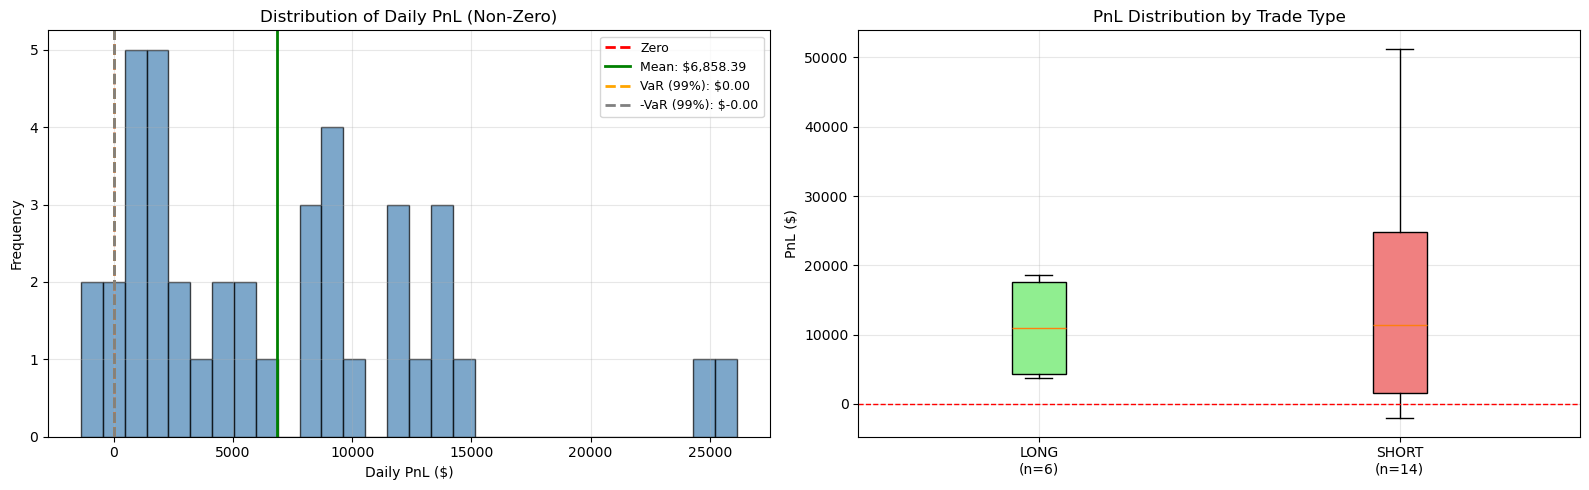


           DAILY PnL STATISTICS
Total Observations:     4690
Non-Zero PnL Days:      40
Mean Daily PnL:         $6,858.39
Std Dev Daily PnL:      $6,482.91
Max Daily Gain:         $26,133.69
Max Daily Loss:         $-1,370.74


In [12]:
## 8. Calculate Performance Metrics (Full Dataset)

#Includes:
#- Basic metrics (Return, Sharpe, Drawdown)
#- Win/Loss streaks
#- Risk-Reward ratios
#- Value at Risk (VaR)

# Ensure equity_curve has values
if len(equity_curve) == 0:
    equity_curve = [initial_capital]
if len(cumulative_pnl) == 0:
    cumulative_pnl = [0]

# Convert to numpy arrays
equity_array = np.array(equity_curve)
cumulative_pnl_array = np.array(cumulative_pnl)

# ========== BASIC METRICS ==========

# Returns (simple)
if len(equity_array) > 1:
    returns = np.diff(equity_array) / np.where(equity_array[:-1] != 0, equity_array[:-1], 1)
else:
    returns = np.array([0])

# Sharpe Ratio (annualized)
sharpe_ratio = np.mean(returns) / np.std(returns) * np.sqrt(252) if np.std(returns) != 0 else 0

# Max Drawdown
running_max = np.maximum.accumulate(equity_array)
drawdown = np.where(running_max != 0, (equity_array - running_max) / running_max, 0)
max_drawdown = drawdown.min()

# Total Return
total_return = (capital - initial_capital) / initial_capital

# ========== WIN/LOSS STREAKS ==========

def calculate_streaks(trade_log):
    """Calculate maximum winning and losing streaks"""
    if not trade_log:
        return 0, 0
    
    results = [1 if t.get('PnL', 0) > 0 else (-1 if t.get('PnL', 0) < 0 else 0) 
               for t in trade_log if 'PnL' in t]
    
    if not results:
        return 0, 0
    
    max_win_streak = 0
    max_loss_streak = 0
    current_win_streak = 0
    current_loss_streak = 0
    
    for result in results:
        if result == 1:  # Win
            current_win_streak += 1
            current_loss_streak = 0
            max_win_streak = max(max_win_streak, current_win_streak)
        elif result == -1:  # Loss
            current_loss_streak += 1
            current_win_streak = 0
            max_loss_streak = max(max_loss_streak, current_loss_streak)
        else:  # Break-even
            current_win_streak = 0
            current_loss_streak = 0
    
    return max_win_streak, max_loss_streak

max_win_streak, max_loss_streak = calculate_streaks(trade_log)

# ========== RISK-REWARD RATIOS ==========

# Get R:R ratios for winning and losing trades
winning_rr = [t['RR_Ratio'] for t in trade_log if 'RR_Ratio' in t and t.get('PnL', 0) > 0]
losing_rr = [t['RR_Ratio'] for t in trade_log if 'RR_Ratio' in t and t.get('PnL', 0) < 0]

avg_winning_rr = np.mean(winning_rr) if winning_rr else 0
avg_losing_rr = np.mean(losing_rr) if losing_rr else 0  # This will be negative

# ========== TRADE STATISTICS ==========

# Separate Long and Short trades
long_trades = [t for t in trade_log if t['Type'] == 'LONG' and 'PnL' in t]
short_trades = [t for t in trade_log if t['Type'] == 'SHORT' and 'PnL' in t]

# Overall Win Rate
wins = [t['PnL'] for t in trade_log if 'PnL' in t and t['PnL'] > 0]
losses = [t['PnL'] for t in trade_log if 'PnL' in t and t['PnL'] < 0]
win_rate = len(wins) / len(trade_log) if trade_log else 0

# Long Win Rate
long_wins = [t['PnL'] for t in long_trades if t['PnL'] > 0]
long_win_rate = len(long_wins) / len(long_trades) if long_trades else 0

# Short Win Rate
short_wins = [t['PnL'] for t in short_trades if t['PnL'] > 0]
short_win_rate = len(short_wins) / len(short_trades) if short_trades else 0

# Profit Factor
profit_factor = sum(wins) / abs(sum(losses)) if losses else np.inf

# Average Win/Loss
avg_win = np.mean(wins) if wins else 0
avg_loss = np.mean(losses) if losses else 0

# ========== PRINT METRICS ==========

print("=" * 60)
print("      STRATEGY PERFORMANCE METRICS (FULL DATASET)")
print("=" * 60)
print(f"Initial Capital:        ${initial_capital:,.2f}")
print(f"Final Capital:          ${capital:,.2f}")
print(f"Total Return:           {total_return:.2%}")
print(f"Sharpe Ratio:           {sharpe_ratio:.2f}")
print(f"Max Drawdown:           {max_drawdown:.2%}")
print("-" * 60)
print(f"Total Trades:           {len(trade_log)}")
print(f"  - Long Trades:        {len(long_trades)}")
print(f"  - Short Trades:       {len(short_trades)}")
print("-" * 60)
print(f"Overall Win Rate:       {win_rate:.2%}")
print(f"Long Win Rate:          {long_win_rate:.2%}")
print(f"Short Win Rate:         {short_win_rate:.2%}")
print(f"Profit Factor:          {profit_factor:.2f}")
print("-" * 60)
print(f"Average Win:            ${avg_win:,.2f}")
print(f"Average Loss:           ${avg_loss:,.2f}")
print("-" * 60)
print("              STREAK ANALYSIS")
print("-" * 60)
print(f"Max Winning Streak:     {max_win_streak} trades")
print(f"Max Losing Streak:      {max_loss_streak} trades")
print("-" * 60)
print("            RISK-REWARD ANALYSIS")
print("-" * 60)
print(f"Avg Winning Trade R:R:  {avg_winning_rr:.2f}R")
print(f"Avg Losing Trade R:R:   {avg_losing_rr:.2f}R")
print("=" * 60)

## 9. Calculate and Plot 10-Period Rolling Value at Risk (VaR)

##**VaR Calculation:**
##- VaR (99%) = Standard Deviation of Daily PnL × 2.33
##- Rolling window: 10 periods

##**Chart Elements:**
##- Red X markers: Daily PnL values
##- Orange line: 10-day rolling VaR (positive)
##- Grey line: Negative 10-day rolling VaR
##- Red dashed line: -30% of current total equity (risk threshold)


# Create DataFrame for VaR analysis
var_df = pd.DataFrame({
    'Brick': range(1, len(daily_pnl) + 1),
    'Daily_PnL': daily_pnl
})

# Get dates for the VaR dataframe
var_dates = renko_df['Date'].iloc[1:len(daily_pnl) + 1].reset_index(drop=True)
if len(var_dates) < len(var_df):
    var_dates = pd.concat([var_dates, pd.Series([renko_df['Date'].iloc[-1]] * (len(var_df) - len(var_dates)))]).reset_index(drop=True)
var_df['Date'] = var_dates

# Calculate 10-period rolling standard deviation of DAILY PnL
var_df['Rolling_StdDev'] = var_df['Daily_PnL'].rolling(window=10).std()

# Calculate VaR at 99% confidence level (2.33 standard deviations)
# VaR = Rolling StdDev of Daily PnL * 2.33
var_df['VaR_99'] = var_df['Rolling_StdDev'] * 2.33

# Calculate negative VaR (for lower bound)
var_df['Neg_VaR_99'] = -var_df['VaR_99']

# Calculate -30% of current total equity (risk threshold)
equity_threshold = -0.30 * capital

# Print VaR statistics
print("=" * 65)
print("       10-PERIOD ROLLING VALUE AT RISK (VaR) - DAILY PnL")
print("=" * 65)
print(f"VaR Confidence Level:     99% (2.33 standard deviations)")
print(f"Rolling Window:           10 periods")
print(f"Calculation:              STDEV(Daily PnL) × 2.33")
print("-" * 65)
current_var = var_df['VaR_99'].iloc[-1]
max_var = var_df['VaR_99'].max()
avg_var = var_df['VaR_99'].mean()
print(f"Current VaR (99%):        ${current_var:,.2f}" if not pd.isna(current_var) else "Current VaR (99%):        N/A")
print(f"Max VaR (99%):            ${max_var:,.2f}" if not pd.isna(max_var) else "Max VaR (99%):            N/A")
print(f"Avg VaR (99%):            ${avg_var:,.2f}" if not pd.isna(avg_var) else "Avg VaR (99%):            N/A")
print("-" * 65)
print(f"Current Total Equity:     ${capital:,.2f}")
print(f"-30% Equity Threshold:    ${equity_threshold:,.2f}")
print("=" * 65)

# ========== PLOT VaR CHART ==========

fig, ax = plt.subplots(figsize=(18, 8))

# X-axis values (brick numbers)
x_values = var_df['Brick'].values

# Plot Daily PnL as red X markers
ax.scatter(x_values, var_df['Daily_PnL'], marker='x', color='red', s=50, 
           label='Daily PnL', zorder=3, alpha=0.7)

# Plot 10-day Rolling VaR (positive) as orange line
ax.plot(x_values, var_df['VaR_99'], color='orange', linewidth=2, 
        label='10-Day Rolling VaR (99%)', zorder=2)

# Plot Negative 10-day Rolling VaR as grey line
ax.plot(x_values, var_df['Neg_VaR_99'], color='grey', linewidth=2, 
        label='Negative VaR (99%)', zorder=2)

# Plot -30% Equity Threshold as red dashed line
ax.axhline(y=equity_threshold, color='red', linestyle='--', linewidth=2, 
           label=f'-30% Equity Threshold (${equity_threshold:,.2f})')

# Add zero line for reference
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

# Fill between VaR lines (optional visual)
ax.fill_between(x_values, var_df['VaR_99'], var_df['Neg_VaR_99'], 
                color='orange', alpha=0.1, label='VaR Range')

# Formatting
ax.set_title('10-Period Rolling Value at Risk (VaR) Based on Daily PnL\n'
             f'Period: {var_df["Date"].min().strftime("%Y-%m-%d")} to {var_df["Date"].max().strftime("%Y-%m-%d")}',
             fontsize=14)
ax.set_xlabel('Brick Number')
ax.set_ylabel('Value ($)')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

# Add secondary x-axis with dates
ax2 = ax.twiny()
num_ticks = 12
tick_indices = np.linspace(0, len(var_df) - 1, num_ticks, dtype=int)
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks([x_values[i] for i in tick_indices])
ax2.set_xticklabels([var_df.loc[i, 'Date'].strftime('%m/%d/%y') for i in tick_indices], fontsize=9)
ax2.set_xlabel('Date', fontsize=10)

plt.tight_layout()
plt.show()

## 10. Alternative VaR Chart with Date X-Axis
# Create a cleaner version with Date on X-axis

fig, ax = plt.subplots(figsize=(18, 8))

# Use dates for x-axis
x_dates = var_df['Date']

# Plot Daily PnL as red X markers
ax.scatter(x_dates, var_df['Daily_PnL'], marker='x', color='red', s=60, 
           label='Daily PnL', zorder=3, alpha=0.8)

# Plot 10-day Rolling VaR (positive) as orange line
ax.plot(x_dates, var_df['VaR_99'], color='orange', linewidth=2.5, 
        label='10-Day Rolling VaR (99%)', zorder=2)

# Plot Negative 10-day Rolling VaR as grey line
ax.plot(x_dates, var_df['Neg_VaR_99'], color='grey', linewidth=2.5, 
        label='Negative VaR (99%)', zorder=2)

# Plot -30% Equity Threshold as red dashed line
ax.axhline(y=equity_threshold, color='red', linestyle='--', linewidth=2.5, 
           label=f'-30% Equity Threshold (${equity_threshold:,.2f})')

# Add zero line for reference
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)

# Fill between VaR lines
ax.fill_between(x_dates, var_df['VaR_99'], var_df['Neg_VaR_99'], 
                color='orange', alpha=0.1)

# Highlight breaches (when daily PnL exceeds VaR bounds)
breaches_high = var_df[var_df['Daily_PnL'] > var_df['VaR_99']]
breaches_low = var_df[var_df['Daily_PnL'] < var_df['Neg_VaR_99']]

if len(breaches_high) > 0:
    ax.scatter(breaches_high['Date'], breaches_high['Daily_PnL'], 
               marker='o', color='green', s=100, edgecolors='black', 
               label=f'VaR Breach (Positive): {len(breaches_high)}', zorder=4)

if len(breaches_low) > 0:
    ax.scatter(breaches_low['Date'], breaches_low['Daily_PnL'], 
               marker='o', color='darkred', s=100, edgecolors='black', 
               label=f'VaR Breach (Negative): {len(breaches_low)}', zorder=4)

# Formatting
ax.set_title('10-Period Rolling Value at Risk (VaR) Based on Daily PnL\n'
             f'VaR = STDEV(Daily PnL) × 2.33 | Current Equity: ${capital:,.2f}',
             fontsize=14)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Value ($)', fontsize=12)
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

# Format x-axis dates
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

# Print VaR breach statistics
print("\n" + "=" * 50)
print("           VaR BREACH ANALYSIS")
print("=" * 50)
print(f"Total Daily PnL Observations:  {len(var_df)}")
print(f"VaR Breaches (Positive):       {len(breaches_high)}")
print(f"VaR Breaches (Negative):       {len(breaches_low)}")
print(f"Breach Rate:                   {(len(breaches_high) + len(breaches_low)) / len(var_df) * 100:.2f}%")
print(f"Expected Breach Rate (99%):    1.00%")
print("=" * 50)

## 11. Daily PnL Distribution Analysis

# Analyze Daily PnL distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Filter non-zero daily PnL values
non_zero_pnl = var_df[var_df['Daily_PnL'] != 0]['Daily_PnL']

# Histogram of Daily PnL
if len(non_zero_pnl) > 0:
    axes[0].hist(non_zero_pnl, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero')
    axes[0].axvline(x=non_zero_pnl.mean(), color='green', linestyle='-', linewidth=2, 
                    label=f'Mean: ${non_zero_pnl.mean():,.2f}')
    axes[0].axvline(x=current_var, color='orange', linestyle='--', linewidth=2, 
                    label=f'VaR (99%): ${current_var:,.2f}')
    axes[0].axvline(x=-current_var, color='grey', linestyle='--', linewidth=2, 
                    label=f'-VaR (99%): ${-current_var:,.2f}')
    axes[0].set_title('Distribution of Daily PnL (Non-Zero)', fontsize=12)
    axes[0].set_xlabel('Daily PnL ($)')
    axes[0].set_ylabel('Frequency')
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)

# Box plot of Daily PnL by trade type
if trade_log:
    trade_pnls = {'LONG': [], 'SHORT': []}
    for trade in trade_log:
        if 'PnL' in trade:
            trade_pnls[trade['Type']].append(trade['PnL'])
    
    # Prepare data for box plot
    box_data = []
    box_labels = []
    for trade_type, pnls in trade_pnls.items():
        if pnls:
            box_data.append(pnls)
            box_labels.append(f"{trade_type}\n(n={len(pnls)})")
    
    if box_data:
        bp = axes[1].boxplot(box_data, labels=box_labels, patch_artist=True)
        colors = ['lightgreen', 'lightcoral']
        for patch, color in zip(bp['boxes'], colors[:len(box_data)]):
            patch.set_facecolor(color)
        axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
        axes[1].set_title('PnL Distribution by Trade Type', fontsize=12)
        axes[1].set_ylabel('PnL ($)')
        axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print Daily PnL statistics
print("\n" + "=" * 50)
print("           DAILY PnL STATISTICS")
print("=" * 50)
print(f"Total Observations:     {len(var_df)}")
print(f"Non-Zero PnL Days:      {len(non_zero_pnl)}")
print(f"Mean Daily PnL:         ${non_zero_pnl.mean():,.2f}" if len(non_zero_pnl) > 0 else "Mean Daily PnL: N/A")
print(f"Std Dev Daily PnL:      ${non_zero_pnl.std():,.2f}" if len(non_zero_pnl) > 0 else "Std Dev Daily PnL: N/A")
print(f"Max Daily Gain:         ${non_zero_pnl.max():,.2f}" if len(non_zero_pnl) > 0 else "Max Daily Gain: N/A")
print(f"Max Daily Loss:         ${non_zero_pnl.min():,.2f}" if len(non_zero_pnl) > 0 else "Max Daily Loss: N/A")
print("=" * 50)

KeyError: 'MA7'

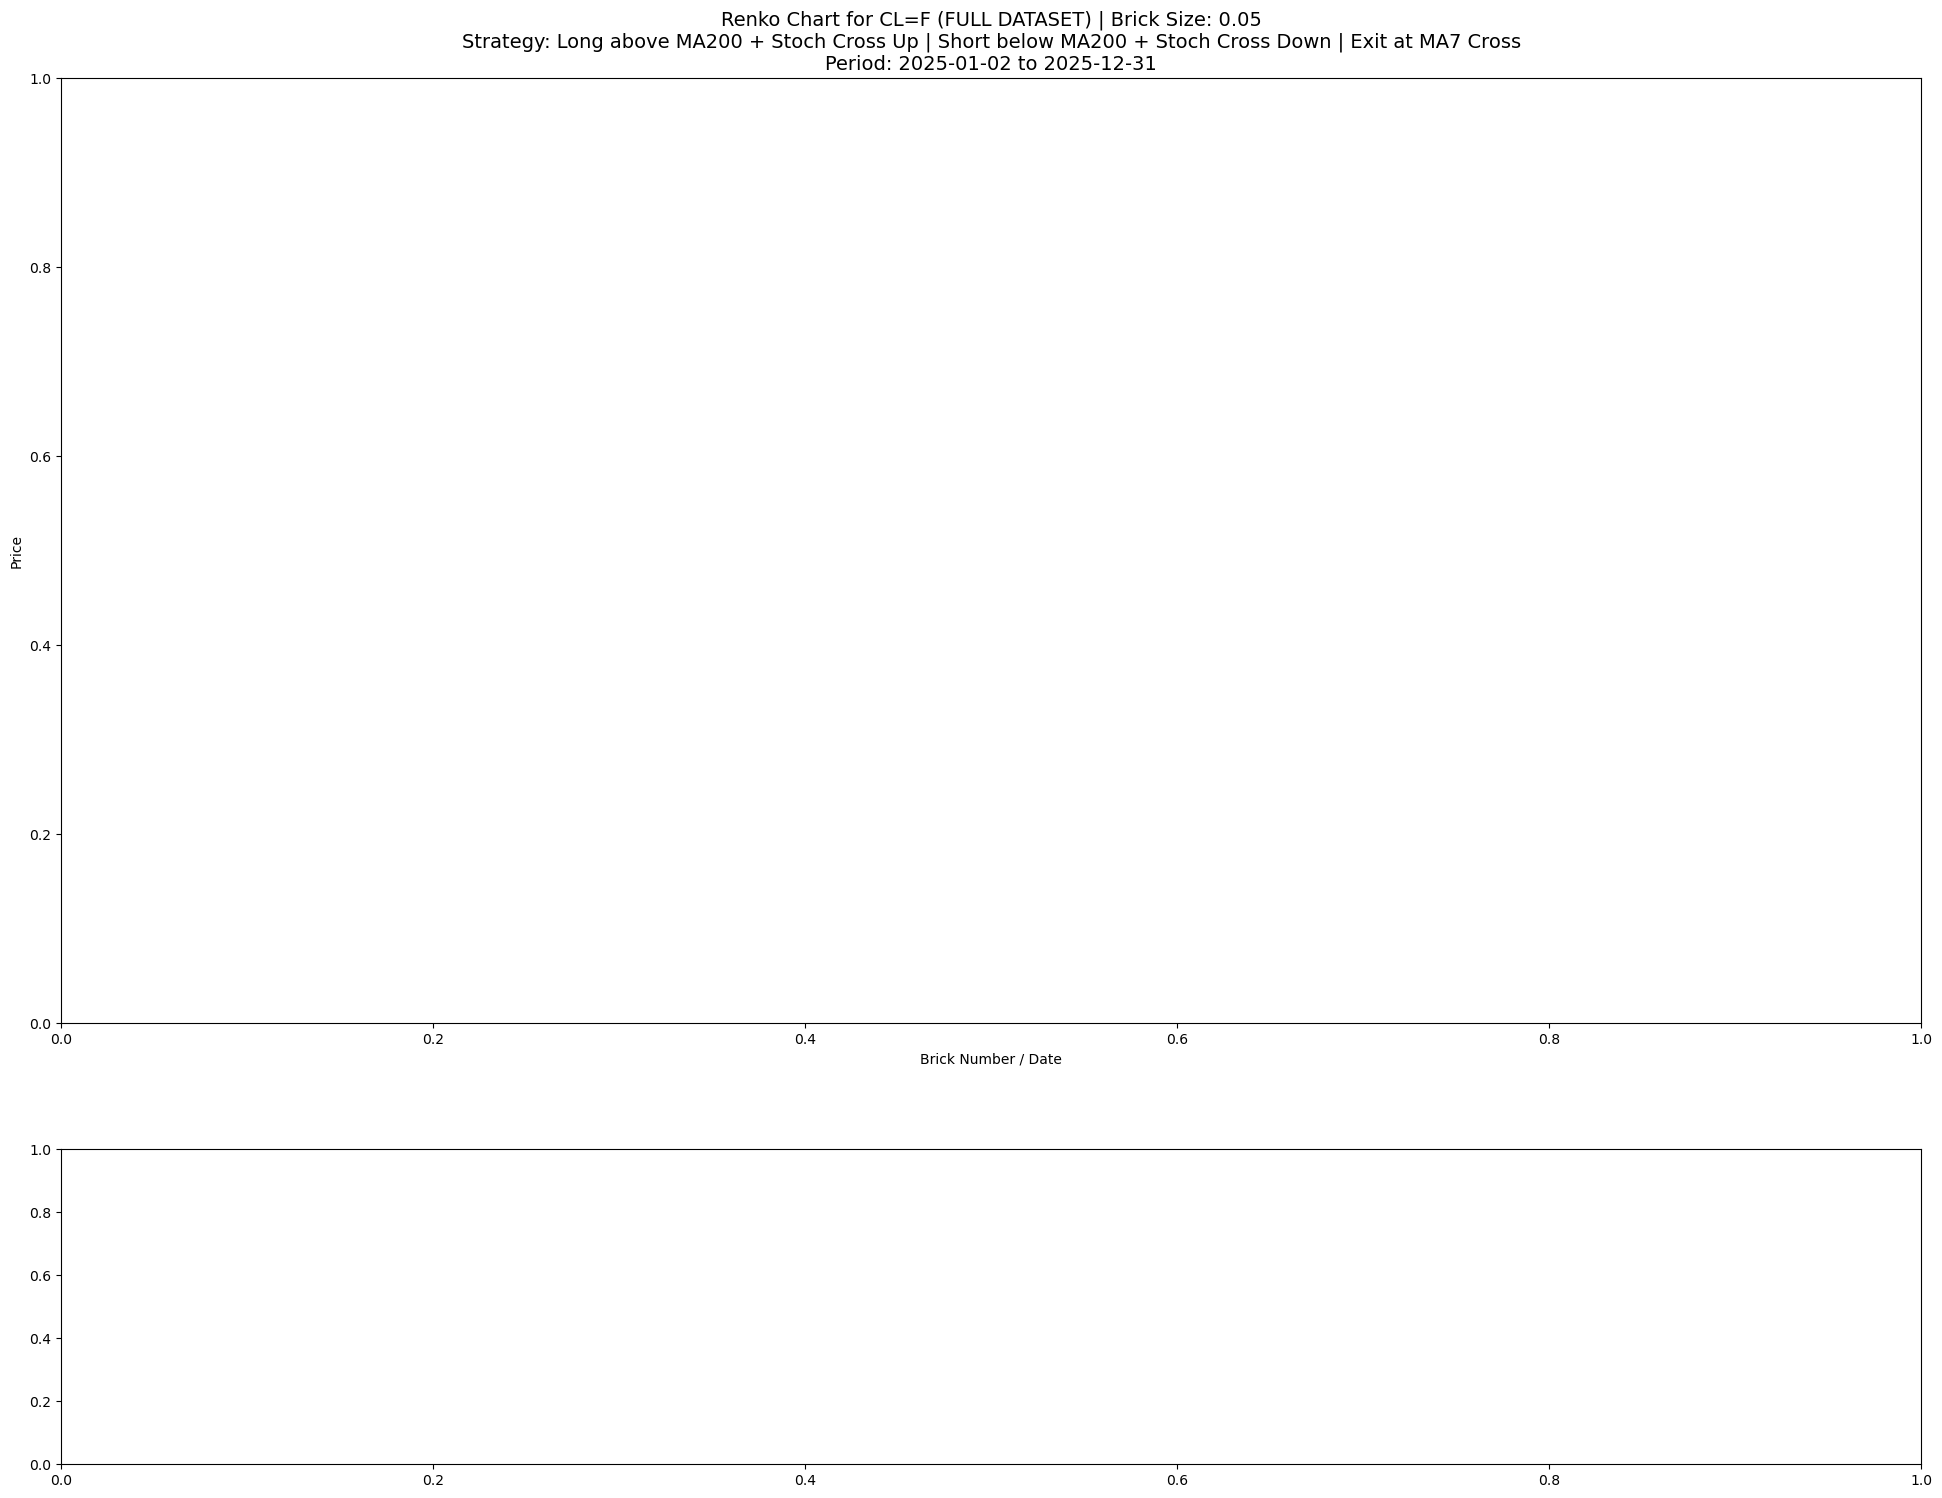

In [13]:
## 9. Plot Renko Chart with Trades (Full Dataset)

# Setup the plot with two subplots: one for Renko, one for Stochastic
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(24, 18), gridspec_kw={'height_ratios': [3, 1]})

# ------------------------------------
# Subplot 1: Renko Chart with Trades
# ------------------------------------

ax1.set_title(f"Renko Chart for {ticker} (FULL DATASET) | Brick Size: {brick_size}\n"
              f"Strategy: Long above MA200 + Stoch Cross Up | Short below MA200 + Stoch Cross Down | Exit at MA7 Cross\n"
              f"Period: {renko_df['Date'].min().strftime('%Y-%m-%d')} to {renko_df['Date'].max().strftime('%Y-%m-%d')}",
              fontsize=14)
ax1.set_xlabel('Brick Number / Date')
ax1.set_ylabel('Price')

# Plot each brick
for i in range(len(x_positions)):
    color = 'green' if directions[i] == 1 else 'red'
    rect = Rectangle(
        (x_positions[i], y_positions[i]), 1, brick_size,
        facecolor=color, edgecolor='black'
    )
    ax1.add_patch(rect)

# Plot Moving Averages
ax1.plot(x_positions, renko_df['MA7'].tolist(), color='orange', linewidth=2, label='MA 7')
ax1.plot(x_positions, renko_df['MA200'].tolist(), color='blue', linewidth=2, label='MA 200')

# Plot Long Entry Points
long_entries = [t for t in trade_log if t['Type'] == 'LONG']
long_entry_bricks = [t['Entry_Brick'] for t in long_entries]
long_entry_prices = [t['Entry_Price'] for t in long_entries]

if long_entry_bricks:
    ax1.scatter(long_entry_bricks, long_entry_prices, marker='^', color='lime', s=200,
                edgecolors='black', linewidths=1.5, label='Long Entry', zorder=5)

# Plot Short Entry Points
short_entries = [t for t in trade_log if t['Type'] == 'SHORT']
short_entry_bricks = [t['Entry_Brick'] for t in short_entries]
short_entry_prices = [t['Entry_Price'] for t in short_entries]

if short_entry_bricks:
    ax1.scatter(short_entry_bricks, short_entry_prices, marker='v', color='magenta', s=200,
                edgecolors='black', linewidths=1.5, label='Short Entry', zorder=5)

# Plot Exit Points
exit_bricks = [t['Exit_Brick'] for t in trade_log if 'Exit_Brick' in t]
exit_prices = [t['Exit_Price'] for t in trade_log if 'Exit_Price' in t]

if exit_bricks:
    ax1.scatter(exit_bricks, exit_prices, marker='x', color='yellow', s=200,
                linewidths=3, label='Exit', zorder=5)

# Draw lines connecting entry to exit
for trade in trade_log:
    if 'Exit_Brick' in trade:
        pnl = trade.get('PnL', 0)
        line_color = 'cyan' if pnl > 0 else 'orange'
        ax1.plot([trade['Entry_Brick'], trade['Exit_Brick']],
                 [trade['Entry_Price'], trade['Exit_Price']],
                 color=line_color, linestyle='--', linewidth=2, alpha=0.8)

# Add date annotations for trades
for trade in trade_log:
    entry_date = trade.get('Entry_Date')
    if entry_date:
        ax1.annotate(entry_date.strftime('%m/%d'),
                     (trade['Entry_Brick'], trade['Entry_Price']),
                     textcoords="offset points", xytext=(0, 15),
                     fontsize=7, ha='center', color='black',
                     bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

# Set axis limits
ax1.set_xlim(-1, max(x_positions) + 2)
ax1.set_ylim(min(y_positions) - brick_size * 3, max(y_positions) + brick_size * 4)

# Create custom x-axis with dates
# Show date labels at regular intervals
num_ticks = 15
tick_indices = np.linspace(0, len(x_positions) - 1, num_ticks, dtype=int)
tick_labels = [f"{x_positions[i]}\n{renko_df.loc[i, 'Date'].strftime('%m/%d/%y')}" for i in tick_indices]
ax1.set_xticks([x_positions[i] for i in tick_indices])
ax1.set_xticklabels(tick_labels, fontsize=8)

# Y-axis ticks
min_price = min(y_positions)
max_price = max(y_positions)
y_tick_step = max(1, int((max_price - min_price) / brick_size / 20))
ax1.set_yticks([min_price + i * brick_size * y_tick_step
                for i in range(int((max_price - min_price) / (brick_size * y_tick_step)) + 3)])

ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left', fontsize=10)

# -------------------
# Subplot 2: Stochastic Oscillator
# -------------------

ax2.set_title("Stochastic Oscillator (10, 3, 3) - Full Dataset", fontsize=14)
ax2.set_xlabel('Brick Number / Date')
ax2.set_ylabel('%K / %D')

ax2.plot(x_positions, renko_df['%K'].tolist(), label='%K', color='orange', linewidth=2)
ax2.plot(x_positions, renko_df['%D'].tolist(), label='%D', color='purple', linewidth=2)

ax2.axhline(80, color='red', linestyle='--', linewidth=1, label='Overbought (80)')
ax2.axhline(20, color='green', linestyle='--', linewidth=1, label='Oversold (20)')

# Mark entry/exit points on stochastic
if long_entry_bricks:
    ax2.scatter(long_entry_bricks, [renko_df.loc[i, '%K'] for i in long_entry_bricks],
                marker='^', color='lime', s=100, edgecolors='black', zorder=5)

if short_entry_bricks:
    ax2.scatter(short_entry_bricks, [renko_df.loc[i, '%K'] for i in short_entry_bricks],
                marker='v', color='magenta', s=100, edgecolors='black', zorder=5)

if exit_bricks:
    ax2.scatter(exit_bricks, [renko_df.loc[i, '%K'] for i in exit_bricks],
                marker='x', color='yellow', s=100, linewidths=2, zorder=5)

ax2.set_xlim(-1, max(x_positions) + 2)
ax2.set_ylim(-10, 110)
ax2.set_xticks([x_positions[i] for i in tick_indices])
ax2.set_xticklabels(tick_labels, fontsize=8)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
## 10. Plot Equity Curve (Full Dataset)
# Create equity curve dataframe with dates
equity_dates = renko_df['Date'].iloc[1:len(equity_curve)+1].reset_index(drop=True)
if len(equity_dates) < len(equity_curve):
    equity_dates = pd.concat([equity_dates, pd.Series([renko_df['Date'].iloc[-1]] * (len(equity_curve) - len(equity_dates)))]).reset_index(drop=True)

plt.figure(figsize=(16, 6))
plt.plot(equity_dates, equity_curve, label='Equity Curve', color='blue', linewidth=2)
plt.axhline(y=initial_capital, color='gray', linestyle='--', label='Initial Capital')
plt.title('Strategy Equity Curve (Full Dataset) - Long & Short Trades', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Capital ($)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

## 11. Plot Drawdown (Full Dataset)
# Use the same equity_dates from previous cell
drawdown_dates = equity_dates[:len(drawdown)]

plt.figure(figsize=(16, 4))
plt.fill_between(drawdown_dates, drawdown[:len(drawdown_dates)] * 100, color='red', alpha=0.7)
plt.title('Drawdown Over Time (Full Dataset)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Drawdown (%)')
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

In [ ]:
## 12. Trade Log Summary (Full Dataset)
# Display trade log as DataFrame
if trade_log:
    trade_log_df = pd.DataFrame(trade_log)
    
    # Format dates
    if 'Entry_Date' in trade_log_df.columns:
        trade_log_df['Entry_Date'] = pd.to_datetime(trade_log_df['Entry_Date']).dt.strftime('%Y-%m-%d')
    if 'Exit_Date' in trade_log_df.columns:
        trade_log_df['Exit_Date'] = pd.to_datetime(trade_log_df['Exit_Date']).dt.strftime('%Y-%m-%d')
    
    # Add profit/loss indicator
    trade_log_df['Result'] = trade_log_df['PnL'].apply(
        lambda x: '✅ WIN' if x > 0 else ('❌ LOSS' if x < 0 else '➖ BE') if pd.notna(x) else '⏳ OPEN'
    )
    
    # Format R:R ratio
    if 'RR_Ratio' in trade_log_df.columns:
        trade_log_df['R:R'] = trade_log_df['RR_Ratio'].apply(lambda x: f"{x:.2f}R" if pd.notna(x) else "N/A")
    
    # Reorder columns
    cols = ['Type', 'Entry_Date', 'Entry_Brick', 'Entry_Price', 'Exit_Date', 'Exit_Brick', 
            'Exit_Price', 'Size', 'PnL', 'R:R', 'Capital', 'Result']
    cols = [c for c in cols if c in trade_log_df.columns]
    trade_log_df = trade_log_df[cols]
    
    display(trade_log_df)
    
    # Summary by trade type
    print("\n" + "=" * 60)
    print("              TRADE SUMMARY BY TYPE")
    print("=" * 60)
    
    for trade_type in ['LONG', 'SHORT']:
        type_trades = [t for t in trade_log if t['Type'] == trade_type and 'PnL' in t]
        if type_trades:
            type_pnl = sum(t['PnL'] for t in type_trades)
            type_wins = len([t for t in type_trades if t['PnL'] > 0])
            type_losses = len([t for t in type_trades if t['PnL'] < 0])
            type_win_rr = [t['RR_Ratio'] for t in type_trades if t.get('PnL', 0) > 0 and 'RR_Ratio' in t]
            type_loss_rr = [t['RR_Ratio'] for t in type_trades if t.get('PnL', 0) < 0 and 'RR_Ratio' in t]
            
            print(f"\n{trade_type} Trades:")
            print(f"  Total: {len(type_trades)}")
            print(f"  Wins: {type_wins} | Losses: {type_losses}")
            print(f"  Total PnL: ${type_pnl:,.2f}")
            print(f"  Avg Winning R:R: {np.mean(type_win_rr):.2f}R" if type_win_rr else "  Avg Winning R:R: N/A")
            print(f"  Avg Losing R:R: {np.mean(type_loss_rr):.2f}R" if type_loss_rr else "  Avg Losing R:R: N/A")
        else:
            print(f"\n{trade_type} Trades: None")
    
    # Streak Analysis
    print("\n" + "=" * 60)
    print("              STREAK ANALYSIS")
    print("=" * 60)
    print(f"Maximum Winning Streak: {max_win_streak} consecutive trades")
    print(f"Maximum Losing Streak:  {max_loss_streak} consecutive trades")
    
else:
    print("No trades executed.")

In [ ]:
## 13. Monthly/Yearly Performance Breakdown
# Create a DataFrame to analyze trades over time
if trade_log:
    trade_analysis_df = pd.DataFrame(trade_log)
    
    # Calculate cumulative PnL
    trade_analysis_df['Cumulative_PnL'] = trade_analysis_df['PnL'].cumsum()
    
    # Plot cumulative PnL by trade number
    plt.figure(figsize=(14, 6))
    
    colors = ['green' if x > 0 else 'red' for x in trade_analysis_df['PnL']]
    
    plt.bar(range(len(trade_analysis_df)), trade_analysis_df['PnL'], color=colors, alpha=0.7, label='Trade PnL')
    plt.plot(range(len(trade_analysis_df)), trade_analysis_df['Cumulative_PnL'], 
             color='blue', linewidth=2, marker='o', markersize=4, label='Cumulative PnL')
    plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
    
    plt.title('Individual Trade PnL and Cumulative PnL (Full Dataset)', fontsize=16)
    plt.xlabel('Trade Number')
    plt.ylabel('PnL ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Long vs Short performance
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Long trades PnL distribution
    long_pnls = [t['PnL'] for t in trade_log if t['Type'] == 'LONG' and 'PnL' in t]
    if long_pnls:
        axes[0].hist(long_pnls, bins=20, color='green', alpha=0.7, edgecolor='black')
        axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
        axes[0].set_title(f'Long Trades PnL Distribution\n(n={len(long_pnls)}, Total=${sum(long_pnls):,.2f})')
        axes[0].set_xlabel('PnL ($)')
        axes[0].set_ylabel('Frequency')
        axes[0].grid(True, alpha=0.3)
    
    # Short trades PnL distribution
    short_pnls = [t['PnL'] for t in trade_log if t['Type'] == 'SHORT' and 'PnL' in t]
    if short_pnls:
        axes[1].hist(short_pnls, bins=20, color='magenta', alpha=0.7, edgecolor='black')
        axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
        axes[1].set_title(f'Short Trades PnL Distribution\n(n={len(short_pnls)}, Total=${sum(short_pnls):,.2f})')
        axes[1].set_xlabel('PnL ($)')
        axes[1].set_ylabel('Frequency')
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No trades to analyze.")